# POF power-scan PSD, SNR, and NEP

This notebook analyzes the 20260709 POF data set by looking at each power level, plotting the PSD of the signal and noise for every available voltage scan, and computing SNR values for each scan. The power levels range from 21mW to 2mW. The voltage level, which determines the amplitude of the piezo's vibration, is scaled from 10V to 1V. The NEP is calcuated for each and displayed alongside the SNR. 

In [1]:
import os
import re
import sys

sys.path.append("../")

import analysis
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal import periodogram

base_path = r"C:\Users\sl57562\The University of Texas at Austin\Acoustic + Calcium - Documents\Acoustic\pof_first_data_set_20260709\20260709"

In [4]:
def analysis_periodogram(power_mw, base_path, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"

    voltage_scans = [
        (float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), folder)
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    ]
    voltage_scans.sort(key=lambda item: item[0], reverse=True)
    voltage_folders = [folder for _, folder in voltage_scans]

    if not voltage_scans:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    print(f"Analyzing {power_pattern}: found {len(voltage_scans)} voltage scans")

    rows, cols = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    results = {}

    for ax, (voltage_value, voltage_folder) in zip(axes, voltage_scans):
        frequency_match = re.search(r"_(\d+(?:\.\d+)?)kHz_", voltage_folder)
        if frequency_match is None:
            continue

        center_frequency_hz = float(frequency_match.group(1)) * 1e3 
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            continue

        print(f"  Processing {voltage_folder} with {len(signal_files)} signal files and {len(noise_files)} noise files")

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)

            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                if freqs is None:
                    #freqs, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                    freqs, psd = periodogram(collection.x, sample_rate, nfft=2**15)
                else:
                    #_, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                    _, psd = periodogram(collection.x, sample_rate, nfft=2**15)

                if group == "signal":
                    signal_psds.append(psd)
                else:
                    noise_psds.append(psd)

        avg_freqs = freqs
        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)

        band_min_idx = np.searchsorted(avg_freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(avg_freqs, center_frequency_hz + band_half_width_hz)
        # print(
        #     f"    In-band bounds (Hz): {avg_freqs[band_min_idx]:.0f} to {avg_freqs[max(band_max_idx - 1, band_min_idx)]:.0f}"
        # )

        wideband_signal_power = np.trapezoid(avg_signal_psd, avg_freqs)
        wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
        snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)

        # #SNR by integration under curve
        # inband_signal_power = np.trapezoid(
        #     avg_signal_psd[band_min_idx:band_max_idx],
        #     avg_freqs[band_min_idx:band_max_idx],
        # )
        # inband_noise_power = np.trapezoid(
        #     avg_noise_psd[band_min_idx:band_max_idx],
        #     avg_freqs[band_min_idx:band_max_idx],
        # )
        # snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)

        #SNR by maximum
        #how wide of a range it scans is determined by the band_half_width_hz variable in def
        band_slice = avg_signal_psd[band_min_idx:band_max_idx]
        local_inband_index = np.argmax(band_slice)
        inband_signal_index = band_min_idx + local_inband_index
        # print(inband_signal_index)
        inband_signal = avg_signal_psd[inband_signal_index]
        print("Signal value:")
        print(inband_signal)
        inband_noise = avg_noise_psd[inband_signal_index]
        #print(inband_noise)
        snr_inband = 10 * np.log10(inband_signal / inband_noise)


        results[voltage_value] = {
            "freqs": avg_freqs,
            "signal": avg_signal_psd,
            "noise": avg_noise_psd,
            "snr_wideband": snr_wideband,
            "snr_inband": snr_inband,
            "band_min_idx": band_min_idx,
            "band_max_idx": band_max_idx,
        }
        def calculate_NEP(snr_inband, voltage_value):
            stroke_distance = [0.05, 0.09, 0.14, 0.19, 0.24, 0.30, 0.35, 0.40, 0.46, 0.44] #stroke distance in nm
            rho = 1.2041 #kg/m^3 at 21 degrees C, desnity of air
            c = 343.21 #m/2 @ 21 degrees C, speed of sound in air
            f = center_frequency_hz
            omega = 2*np.pi*f
            X_o = stroke_distance[int(voltage_value-1)] * 1e-9
            P = rho*c*omega*X_o
            if snr_inband < 1.0:
                NEP = "Null"
            else:
                NEP = P / snr_inband 
                NEP = round(NEP, 4)
            return NEP


        ax.loglog(avg_freqs, avg_signal_psd, label="Signal", alpha=0.7)
        ax.loglog(avg_freqs, avg_noise_psd, label="Noise", alpha=0.7)
        # ax.axvline(avg_freqs[band_min_idx], color="k", linestyle="--", linewidth=0.5)
        # ax.axvline(avg_freqs[max(band_max_idx - 1, band_min_idx)], color="k", linestyle="--", linewidth=0.5)
        ax.set_title(f"{voltage_value} V\nIn-band SNR: {snr_inband:.1f} dB\nNEP: {calculate_NEP(snr_inband, voltage_value)} Pa")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_ylim(1e-16, 1e-6)

        print(f"    In-band SNR: {snr_inband:.2f} dB | Wideband SNR: {snr_wideband:.2f} dB")
        print(f"    NEP: {calculate_NEP(snr_inband, voltage_value)} Pa")

    for ax in axes[len(results):]:
        ax.set_visible(False)

    fig.suptitle(f"{power_mw} mW PSDs and SNRs")
    fig.tight_layout()
    #plt.show()

# plots snr vs voltage    
    # voltage_values = sorted(results.keys())
    # snr_values = [results[voltage]["snr_inband"] for voltage in voltage_values]

    # fig2, ax2 = plt.subplots(figsize=(6, 4))
    # ax2.plot(voltage_values, snr_values, "o-", color="tab:blue")
    # ax2.set_xlabel("Voltage (V)")
    # ax2.set_ylabel("In-band SNR (dB)")
    # ax2.set_title(f"{power_mw} mW: SNR vs voltage")
    # ax2.grid(True, alpha=0.3)
    # fig2.tight_layout()
    # plt.show()

    return results

Analyzing pof_21mW: found 10 voltage scans
  Processing pof_21mW_109kHz_10V with 5 signal files and 5 noise files
Signal value:
3.9871703708695424e-11
    In-band SNR: 9.30 dB | Wideband SNR: 0.06 dB
    NEP: 0.0134 Pa
  Processing pof_21mW_109kHz_9V with 5 signal files and 5 noise files
Signal value:
7.338931021509121e-11
    In-band SNR: 11.95 dB | Wideband SNR: 0.09 dB
    NEP: 0.0109 Pa
  Processing pof_21mW_109kHz_8V with 5 signal files and 5 noise files
Signal value:
5.936820635154448e-11
    In-band SNR: 11.03 dB | Wideband SNR: 0.06 dB
    NEP: 0.0103 Pa
  Processing pof_21mW_109kHz_7V with 5 signal files and 5 noise files
Signal value:
3.631325004087344e-11
    In-band SNR: 8.90 dB | Wideband SNR: 0.10 dB
    NEP: 0.0111 Pa
  Processing pof_21mW_109kHz_6V with 5 signal files and 5 noise files
Signal value:
1.9533249300225417e-11
    In-band SNR: 6.20 dB | Wideband SNR: 0.12 dB
    NEP: 0.0137 Pa
  Processing pof_21mW_109kHz_5V with 5 signal files and 5 noise files
Signal value

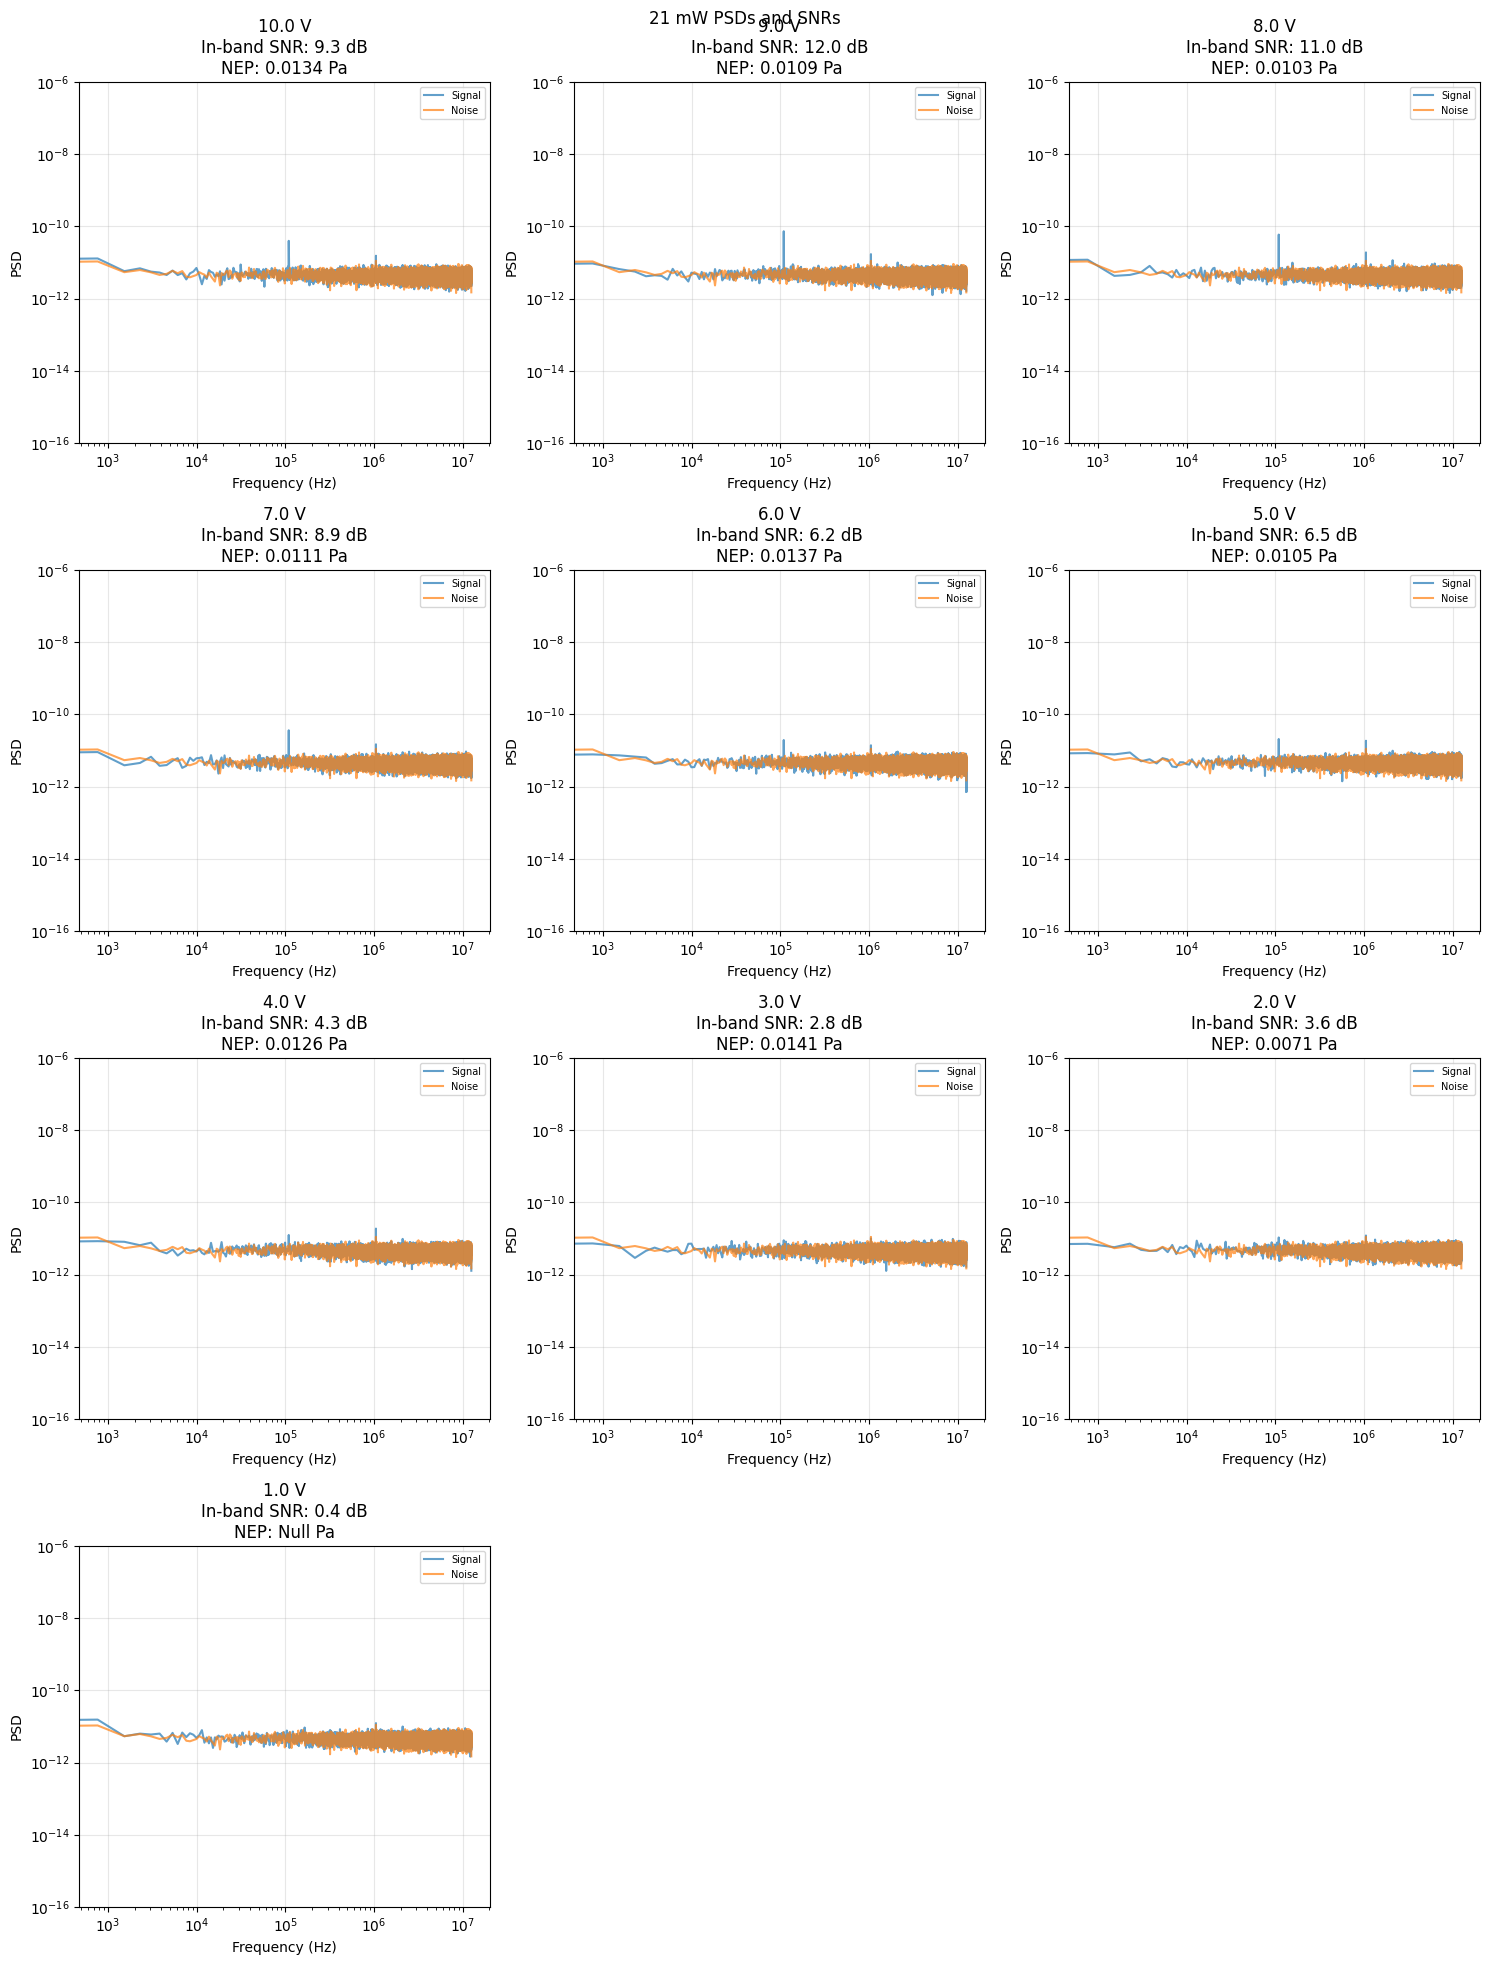

In [5]:
results = analysis_periodogram(21, base_path)

In [104]:
def analysis_welches(power_mw, base_path, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"

    voltage_scans = [
        (float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), folder)
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    ]
    voltage_scans.sort(key=lambda item: item[0], reverse=True)
    voltage_folders = [folder for _, folder in voltage_scans]

    if not voltage_scans:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    print(f"Analyzing {power_pattern}: found {len(voltage_scans)} voltage scans")

    rows, cols = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    results = {}

    for ax, (voltage_value, voltage_folder) in zip(axes, voltage_scans):
        frequency_match = re.search(r"_(\d+(?:\.\d+)?)kHz_", voltage_folder)
        if frequency_match is None:
            continue

        center_frequency_hz = float(frequency_match.group(1)) * 1e3 
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            continue

        print(f"  Processing {voltage_folder} with {len(signal_files)} signal files and {len(noise_files)} noise files")

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)

            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                if freqs is None:
                    freqs, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                else:
                    _, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)

                if group == "signal":
                    signal_psds.append(psd)
                else:
                    noise_psds.append(psd)

        avg_freqs = freqs
        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)

        band_min_idx = np.searchsorted(avg_freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(avg_freqs, center_frequency_hz + band_half_width_hz)
        # print(
        #     f"    In-band bounds (Hz): {avg_freqs[band_min_idx]:.0f} to {avg_freqs[max(band_max_idx - 1, band_min_idx)]:.0f}"
        # )

        wideband_signal_power = np.trapezoid(avg_signal_psd, avg_freqs)
        wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
        snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)

        # SNR by integration

        inband_signal_power = np.trapezoid(
            avg_signal_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        inband_noise_power = np.trapezoid(
            avg_noise_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)

        #SNR by maximum
        # #how wide of a range it scans is determined by the band_half_width_hz variable in def
        # band_slice = avg_signal_psd[band_min_idx:band_max_idx]
        # local_inband_index = np.argmax(band_slice)
        # inband_signal_index = band_min_idx + local_inband_index
        # #print(inband_signal_index)
        # inband_signal = avg_signal_psd[inband_signal_index]
        # #print(inband_signal)
        # inband_noise = avg_noise_psd[inband_signal_index]
        # #print(inband_noise)
        # snr_inband = 10 * np.log10(inband_signal / inband_noise)

        results[voltage_value] = {
            "freqs": avg_freqs,
            "signal": avg_signal_psd,
            "noise": avg_noise_psd,
            "snr_wideband": snr_wideband,
            "snr_inband": snr_inband,
            "band_min_idx": band_min_idx,
            "band_max_idx": band_max_idx,
        }

        def calculate_NEP(snr_inband, voltage_value):
            stroke_distance = [0.05, 0.09, 0.14, 0.19, 0.24, 0.30, 0.35, 0.40, 0.46, 0.44] #stroke distance in nm
            rho = 1.2041 #kg/m^3 at 21 degrees C, desnity of air
            c = 343.21 #m/2 @ 21 degrees C, speed of sound in air
            f = center_frequency_hz
            omega = 2*np.pi*f
            X_o = stroke_distance[int(voltage_value-1)] * 1e-9
            P = rho*c*omega*X_o
            if snr_inband < 1.0:
                NEP = "Null"
            else:
                NEP = P / snr_inband 
                NEP = round(NEP, 4)
            return NEP

        ax.loglog(avg_freqs, avg_signal_psd, label="Signal", alpha=0.7)
        ax.loglog(avg_freqs, avg_noise_psd, label="Noise", alpha=0.7)
        # ax.axvline(avg_freqs[band_min_idx], color="k", linestyle="--", linewidth=0.5)
        # ax.axvline(avg_freqs[max(band_max_idx - 1, band_min_idx)], color="k", linestyle="--", linewidth=0.5)

        ax.set_title(f"{voltage_value} V\nIn-band SNR: {snr_inband:.1f} dB\nNEP: {calculate_NEP(snr_inband, voltage_value)} Pa")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_ylim(1e-16, 1e-6)

        print(f"    In-band SNR: {snr_inband:.2f} dB")
        print(f"    NEP: {calculate_NEP(snr_inband, voltage_value)} Pa")

    for ax in axes[len(results):]:
        ax.set_visible(False)

    fig.suptitle(f"{power_mw} mW PSDs and SNRs")
    fig.tight_layout()
    # plt.show()

# plots snr vs voltage
    # voltage_values = sorted(results.keys())
    # snr_values = [results[voltage]["snr_inband"] for voltage in voltage_values]

    # fig2, ax2 = plt.subplots(figsize=(6, 4))
    # ax2.plot(voltage_values, snr_values, "o-", color="tab:blue")
    # ax2.set_xlabel("Voltage (V)")
    # ax2.set_ylabel("In-band SNR (dB)")
    # ax2.set_title(f"{power_mw} mW: SNR vs voltage")
    # ax2.grid(True, alpha=0.3)
    # fig2.tight_layout()
    # plt.show()

    return results




In [ ]:
#weiner filter: this type of data has issues with spectral subtraction and doesn't translate smoothly. Not fit tool for this data type.
def analysis_weiner_filter(power_mw, base_path, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"

    voltage_scans = [
        (float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), folder)
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    ]
    voltage_scans.sort(key=lambda item: item[0], reverse=True)
    voltage_folders = [folder for _, folder in voltage_scans]

    if not voltage_scans:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    print(f"Analyzing {power_pattern}: found {len(voltage_scans)} voltage scans")

    rows, cols = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    axes = axes.flatten()

    results = {}

    for ax, (voltage_value, voltage_folder) in zip(axes, voltage_scans):
        frequency_match = re.search(r"_(\d+(?:\.\d+)?)kHz_", voltage_folder)
        if frequency_match is None:
            continue

        center_frequency_hz = float(frequency_match.group(1)) * 1e3 
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(5) #drop to 5 to exclude data thats further drifted from alignement
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            continue

        print(f"  Processing {voltage_folder} with {len(signal_files)} signal files and {len(noise_files)} noise files")

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)

            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                if freqs is None:
                    freqs, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)
                else:
                    _, psd = welch(collection.x, sample_rate, nfft=2**15, nperseg=2**14)

                if group == "signal":
                    signal_psds.append(psd)
                else:
                    noise_psds.append(psd)

        avg_freqs = freqs
        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)

        # Spectral subtraction estimate for the Wiener filter target
        cleaned_psd = np.maximum(avg_signal_psd - avg_noise_psd, 0.0)

        # Per-bin Wiener gain using the cleaned PSD estimate
        gain = cleaned_psd / (cleaned_psd + avg_noise_psd)
        filtered_psd = gain * avg_signal_psd

        band_min_idx = np.searchsorted(avg_freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(avg_freqs, center_frequency_hz + band_half_width_hz)
        print(
            f"    In-band bounds (Hz): {avg_freqs[band_min_idx]:.0f} to {avg_freqs[max(band_max_idx - 1, band_min_idx)]:.0f}"
        )

        wideband_signal_power = np.trapezoid(filtered_psd, avg_freqs)
        wideband_noise_power = np.trapezoid(avg_noise_psd, avg_freqs)
        snr_wideband = 10 * np.log10(wideband_signal_power / wideband_noise_power)

        inband_signal_power = np.trapezoid(
            filtered_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        inband_noise_power = np.trapezoid(
            avg_noise_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        snr_inband = 10 * np.log10(inband_signal_power / inband_noise_power)

        results[voltage_value] = {
            "gain": gain,
            "freqs": avg_freqs,
            "filtered_psd": filtered_psd,
            "snr_wideband": snr_wideband,
            "snr_inband": snr_inband,
            "band_min_idx": band_min_idx,
            "band_max_idx": band_max_idx,
        }

        def calculate_NEP(snr_inband, voltage_value):
            stroke_distance = [0.05, 0.09, 0.14, 0.19, 0.24, 0.30, 0.35, 0.40, 0.46, 0.44] #stroke distance in nm
            rho = 1.2041 #kg/m^3 at 21 degrees C, desnity of air
            c = 343.21 #m/2 @ 21 degrees C, speed of sound in air
            f = center_frequency_hz
            omega = 2*np.pi*f
            X_o = stroke_distance[int(voltage_value-1)] * 1e-9
            P = rho*c*omega*X_o
            if snr_inband < 1.0:
                NEP = "Null"
            else:
                NEP = P / snr_inband 
                NEP = round(NEP, 4)
            return NEP

        ax.loglog(avg_freqs, filtered_psd, label="Wiener-filtered PSD", alpha=0.7)
        ax.loglog(avg_freqs, avg_noise_psd, label="Noise", alpha=0.7)
        # ax.axvline(avg_freqs[band_min_idx], color="k", linestyle="--", linewidth=0.5)
        # ax.axvline(avg_freqs[max(band_max_idx - 1, band_min_idx)], color="k", linestyle="--", linewidth=0.5)

        ax.set_title(f"{voltage_value} V\nIn-band SNR: {snr_inband:.1f} dB\nNEP: {calculate_NEP(snr_inband, voltage_value)} Pa")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("PSD")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)
        ax.set_ylim(0, 1e-6)

        print(f"    In-band SNR: {snr_inband:.2f} dB | Wideband SNR: {snr_wideband:.2f} dB")
        print(f"    NEP: {calculate_NEP(snr_inband, voltage_value)} Pa")

    fig.suptitle(f"{power_mw} mW Wiener-filtered PSDs and SNRs")
    fig.tight_layout()
    plt.show()
    return results

#usage
results_21mW = analysis_weiner_filter(21, base_path)

In [ ]:
# Digital lock-in amplifier at the carrier frequency
#
# This helper mirrors the structure of the earlier analysis_* functions:
# 1. discover the relevant voltage folders for a given power level,
# 2. load the signal and noise scans,
# 3. estimate PSDs with Welch, and
# 4. apply a lock-in demodulation at the carrier frequency.
#
# The reported SNR here is the digital lock-in SNR, i.e. the ratio of the
# recovered carrier amplitude in the signal channel to the recovered carrier
# amplitude in the noise channel.

def digital_lock_in(power_mw, base_path, center_frequency_khz=109, band_half_width_hz=1e3):
    power_pattern = f"pof_{power_mw}mW"
    noise_folder = f"{power_pattern}_noise"
    center_frequency_hz = center_frequency_khz * 1e3

    voltage_scans = [
        (float(re.search(r"_(\d+(?:\.\d+)?)V$", folder).group(1)), folder)
        for folder in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, folder))
        and folder.startswith(f"{power_pattern}_")
        and "noise" not in folder
        and re.search(r"_(\d+(?:\.\d+)?)V$", folder)
    ]
    voltage_scans.sort(key=lambda item: item[0], reverse=True)

    if not voltage_scans:
        raise ValueError(f"No voltage scan folders found for {power_pattern}")

    print(f"Digital lock-in analysis for {power_pattern}: found {len(voltage_scans)} voltage scans")

    results = {}

    for voltage_value, voltage_folder in voltage_scans:
        signal_path = os.path.join(base_path, voltage_folder)
        noise_path = os.path.join(base_path, noise_folder)

        signal_files = [
            os.path.join(signal_path, f"iter_{x}.tdms")
            for x in range(5)
            if os.path.exists(os.path.join(signal_path, f"iter_{x}.tdms"))
        ]
        noise_files = [
            os.path.join(noise_path, f"iter_{x}.tdms")
            for x in range(5)
            if os.path.exists(os.path.join(noise_path, f"iter_{x}.tdms"))
        ]

        if not signal_files or not noise_files:
            print(f"Skipping {voltage_folder}: missing signal or noise files")
            continue

        print(f"  Processing {voltage_folder} with {len(signal_files)} signal files and {len(noise_files)} noise files")

        system = analysis.System(
            f"{power_pattern}_{voltage_folder}",
            signal_files + noise_files,
            channel="X",
            set_data=True,
        )

        freqs = None
        signal_psds = []
        noise_psds = []
        signal_lockin_psds = []
        noise_lockin_psds = []
        signal_lockin_amplitudes = []
        noise_lockin_amplitudes = []

        for dataset_idx, dataset in enumerate(system.get_data()):
            dataset.apply("detrend", mode="linear", inplace=True)
            group = "signal" if dataset_idx < len(signal_files) else "noise"

            for collection in dataset.collection:
                sample_rate = getattr(dataset, "r", None)
                t = collection.t
                x = collection.x - np.mean(collection.x)

                if freqs is None:
                    freqs, psd = welch(x, sample_rate, nfft=2**15, nperseg=2**14)
                else:
                    _, psd = welch(x, sample_rate, nfft=2**15, nperseg=2**14)

                if group == "signal":
                    signal_psds.append(psd)
                else:
                    noise_psds.append(psd)

                # Digital lock-in amplifier:
                # Multiply the time-domain trace by a complex reference at the
                # carrier frequency. This shifts the carrier to DC so the
                # resulting PSD represents the post-lock-in spectrum.
                reference = np.exp(-1j * 2 * np.pi * center_frequency_hz * t)
                mixed_signal = x * reference
                lockin_freqs, lockin_psd = welch(mixed_signal, sample_rate, nfft=2**15, nperseg=2**14)

                in_phase = np.mean(mixed_signal.real)
                quadrature = np.mean(mixed_signal.imag)
                lockin_amplitude = np.sqrt(in_phase**2 + quadrature**2)

                if group == "signal":
                    signal_lockin_psds.append(lockin_psd)
                    signal_lockin_amplitudes.append(lockin_amplitude)
                else:
                    noise_lockin_psds.append(lockin_psd)
                    noise_lockin_amplitudes.append(lockin_amplitude)

        avg_freqs = freqs
        avg_signal_psd = np.mean(np.asarray(signal_psds), axis=0)
        avg_noise_psd = np.mean(np.asarray(noise_psds), axis=0)
        avg_signal_lockin_psd = np.mean(np.asarray(signal_lockin_psds), axis=0)
        avg_noise_lockin_psd = np.mean(np.asarray(noise_lockin_psds), axis=0)

        band_min_idx = np.searchsorted(avg_freqs, center_frequency_hz - band_half_width_hz)
        band_max_idx = np.searchsorted(avg_freqs, center_frequency_hz + band_half_width_hz)

        inband_signal_power = np.trapezoid(
            avg_signal_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        inband_noise_power = np.trapezoid(
            avg_noise_psd[band_min_idx:band_max_idx],
            avg_freqs[band_min_idx:band_max_idx],
        )
        psd_snr_db = 10 * np.log10(inband_signal_power / max(inband_noise_power, 1e-30))

        # Lock-in SNR from recovered complex amplitudes.
        signal_amp = np.mean(signal_lockin_amplitudes)
        noise_amp = np.mean(noise_lockin_amplitudes)
        lockin_snr_db = 20 * np.log10(signal_amp / max(noise_amp, 1e-30))

        results[voltage_value] = {
            "freqs": avg_freqs,
            "signal_psd": avg_signal_psd,
            "noise_psd": avg_noise_psd,
            "signal_lockin_psd": avg_signal_lockin_psd,
            "noise_lockin_psd": avg_noise_lockin_psd,
            "lockin_freqs": lockin_freqs,
            "signal_lockin_amplitude": signal_amp,
            "noise_lockin_amplitude": noise_amp,
            "psd_snr_db": psd_snr_db,
            "lockin_snr_db": lockin_snr_db,
            "band_min_idx": band_min_idx,
            "band_max_idx": band_max_idx,
        }

        print(
            f"    Voltage={voltage_value:.2f} V | "
            f"PSD SNR={psd_snr_db:.2f} dB | "
            f"Lock-in SNR={lockin_snr_db:.2f} dB"
        )

    return results

#usage
digital_lock_in(21, base_path)

##PSD generated via Welch's method: smoother, easier to read PSD, but lower SNR.

Analyzing pof_21mW: found 10 voltage scans
  Processing pof_21mW_109kHz_10V with 5 signal files and 5 noise files
    In-band SNR: 5.38 dB
    NEP: 0.0231 Pa
  Processing pof_21mW_109kHz_9V with 5 signal files and 5 noise files
    In-band SNR: 7.43 dB
    NEP: 0.0175 Pa
  Processing pof_21mW_109kHz_8V with 5 signal files and 5 noise files
    In-band SNR: 6.67 dB
    NEP: 0.017 Pa
  Processing pof_21mW_109kHz_7V with 5 signal files and 5 noise files
    In-band SNR: 5.12 dB
    NEP: 0.0193 Pa
  Processing pof_21mW_109kHz_6V with 5 signal files and 5 noise files
    In-band SNR: 3.33 dB
    NEP: 0.0255 Pa
  Processing pof_21mW_109kHz_5V with 5 signal files and 5 noise files
    In-band SNR: 2.70 dB
    NEP: 0.0251 Pa
  Processing pof_21mW_109kHz_4V with 5 signal files and 5 noise files
    In-band SNR: 2.06 dB
    NEP: 0.0261 Pa
  Processing pof_21mW_109kHz_3V with 5 signal files and 5 noise files
    In-band SNR: 1.29 dB
    NEP: 0.0306 Pa
  Processing pof_21mW_109kHz_2V with 5 signal

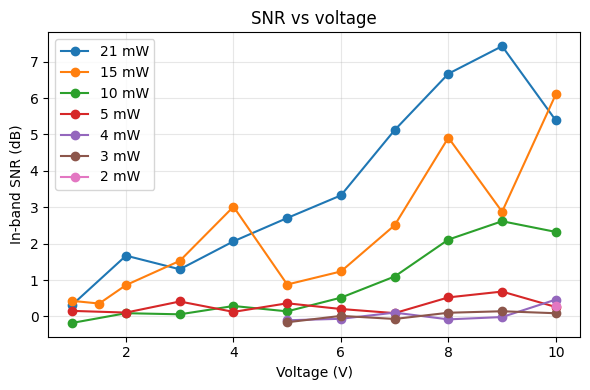

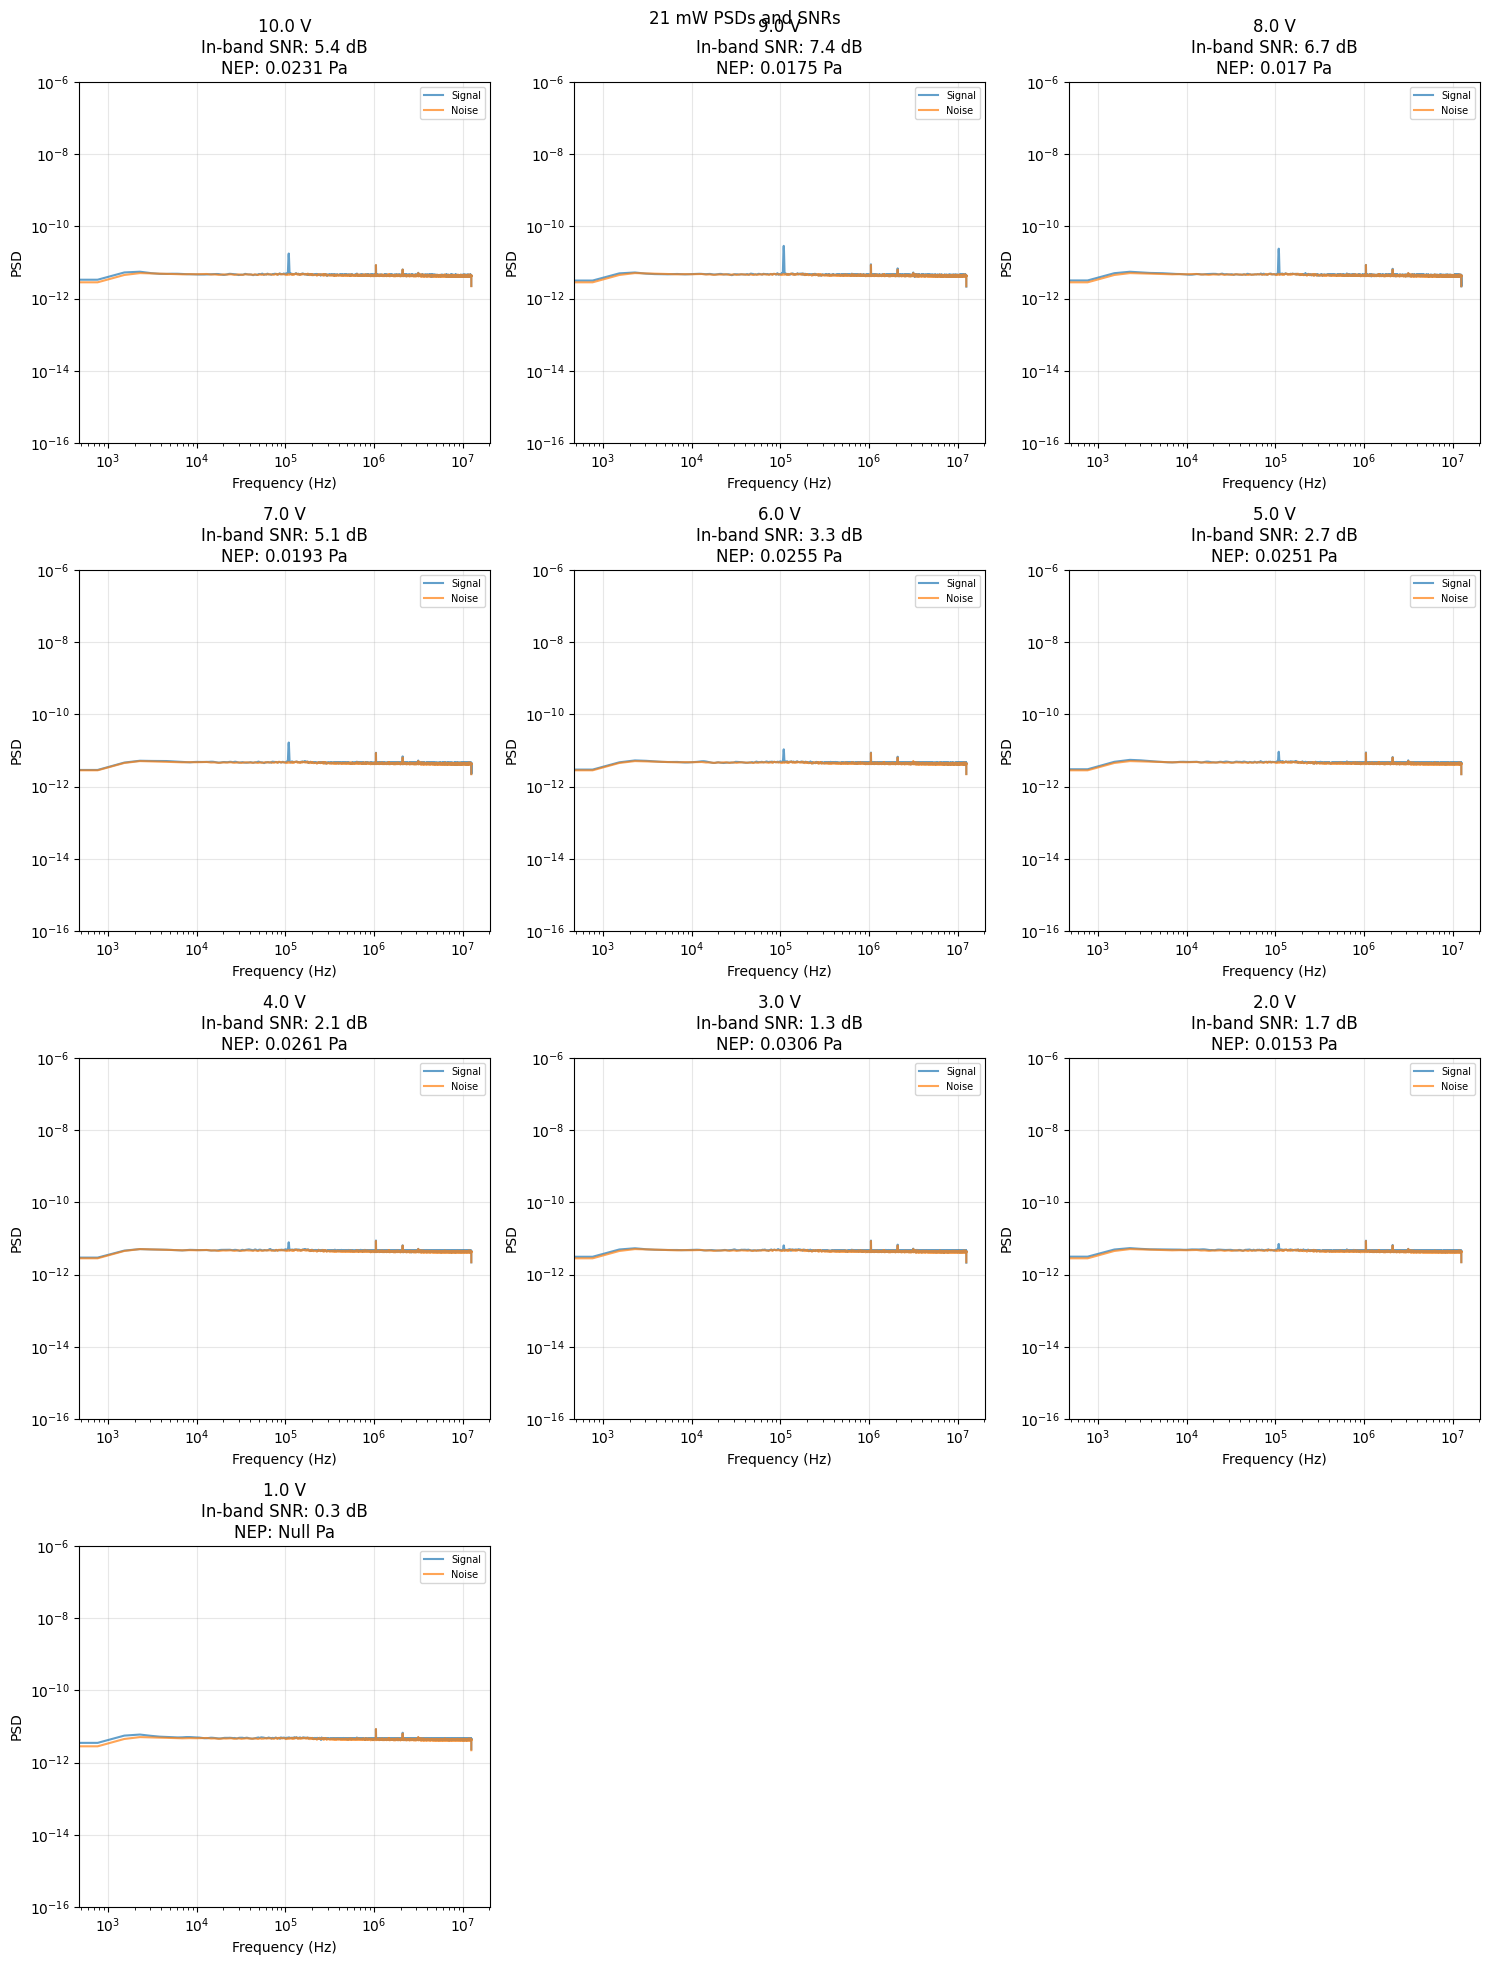

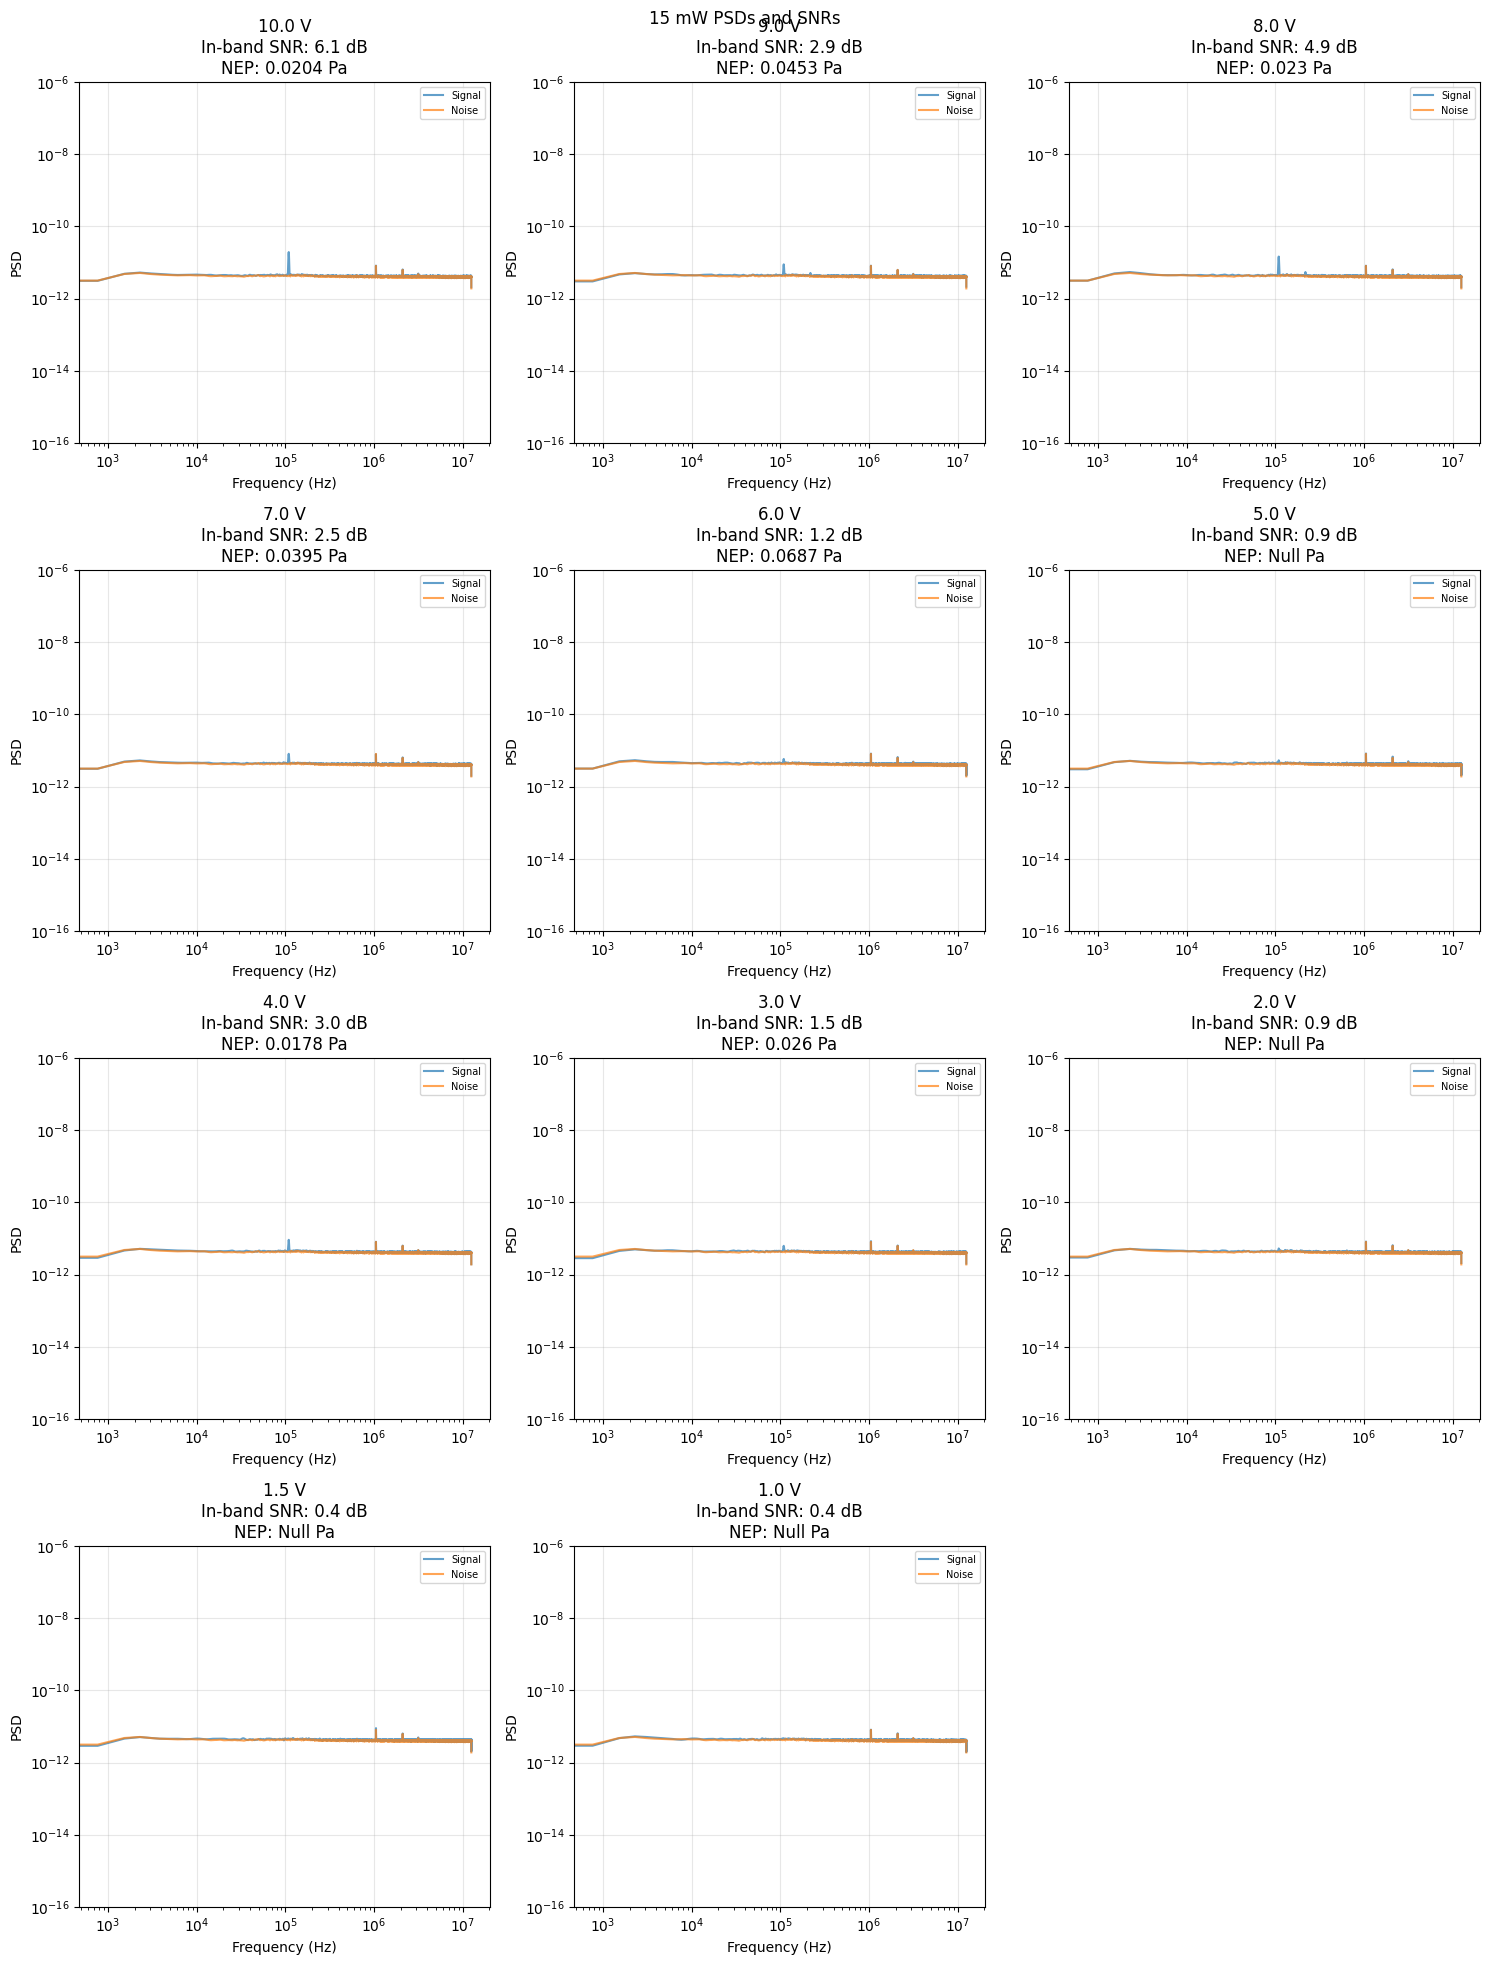

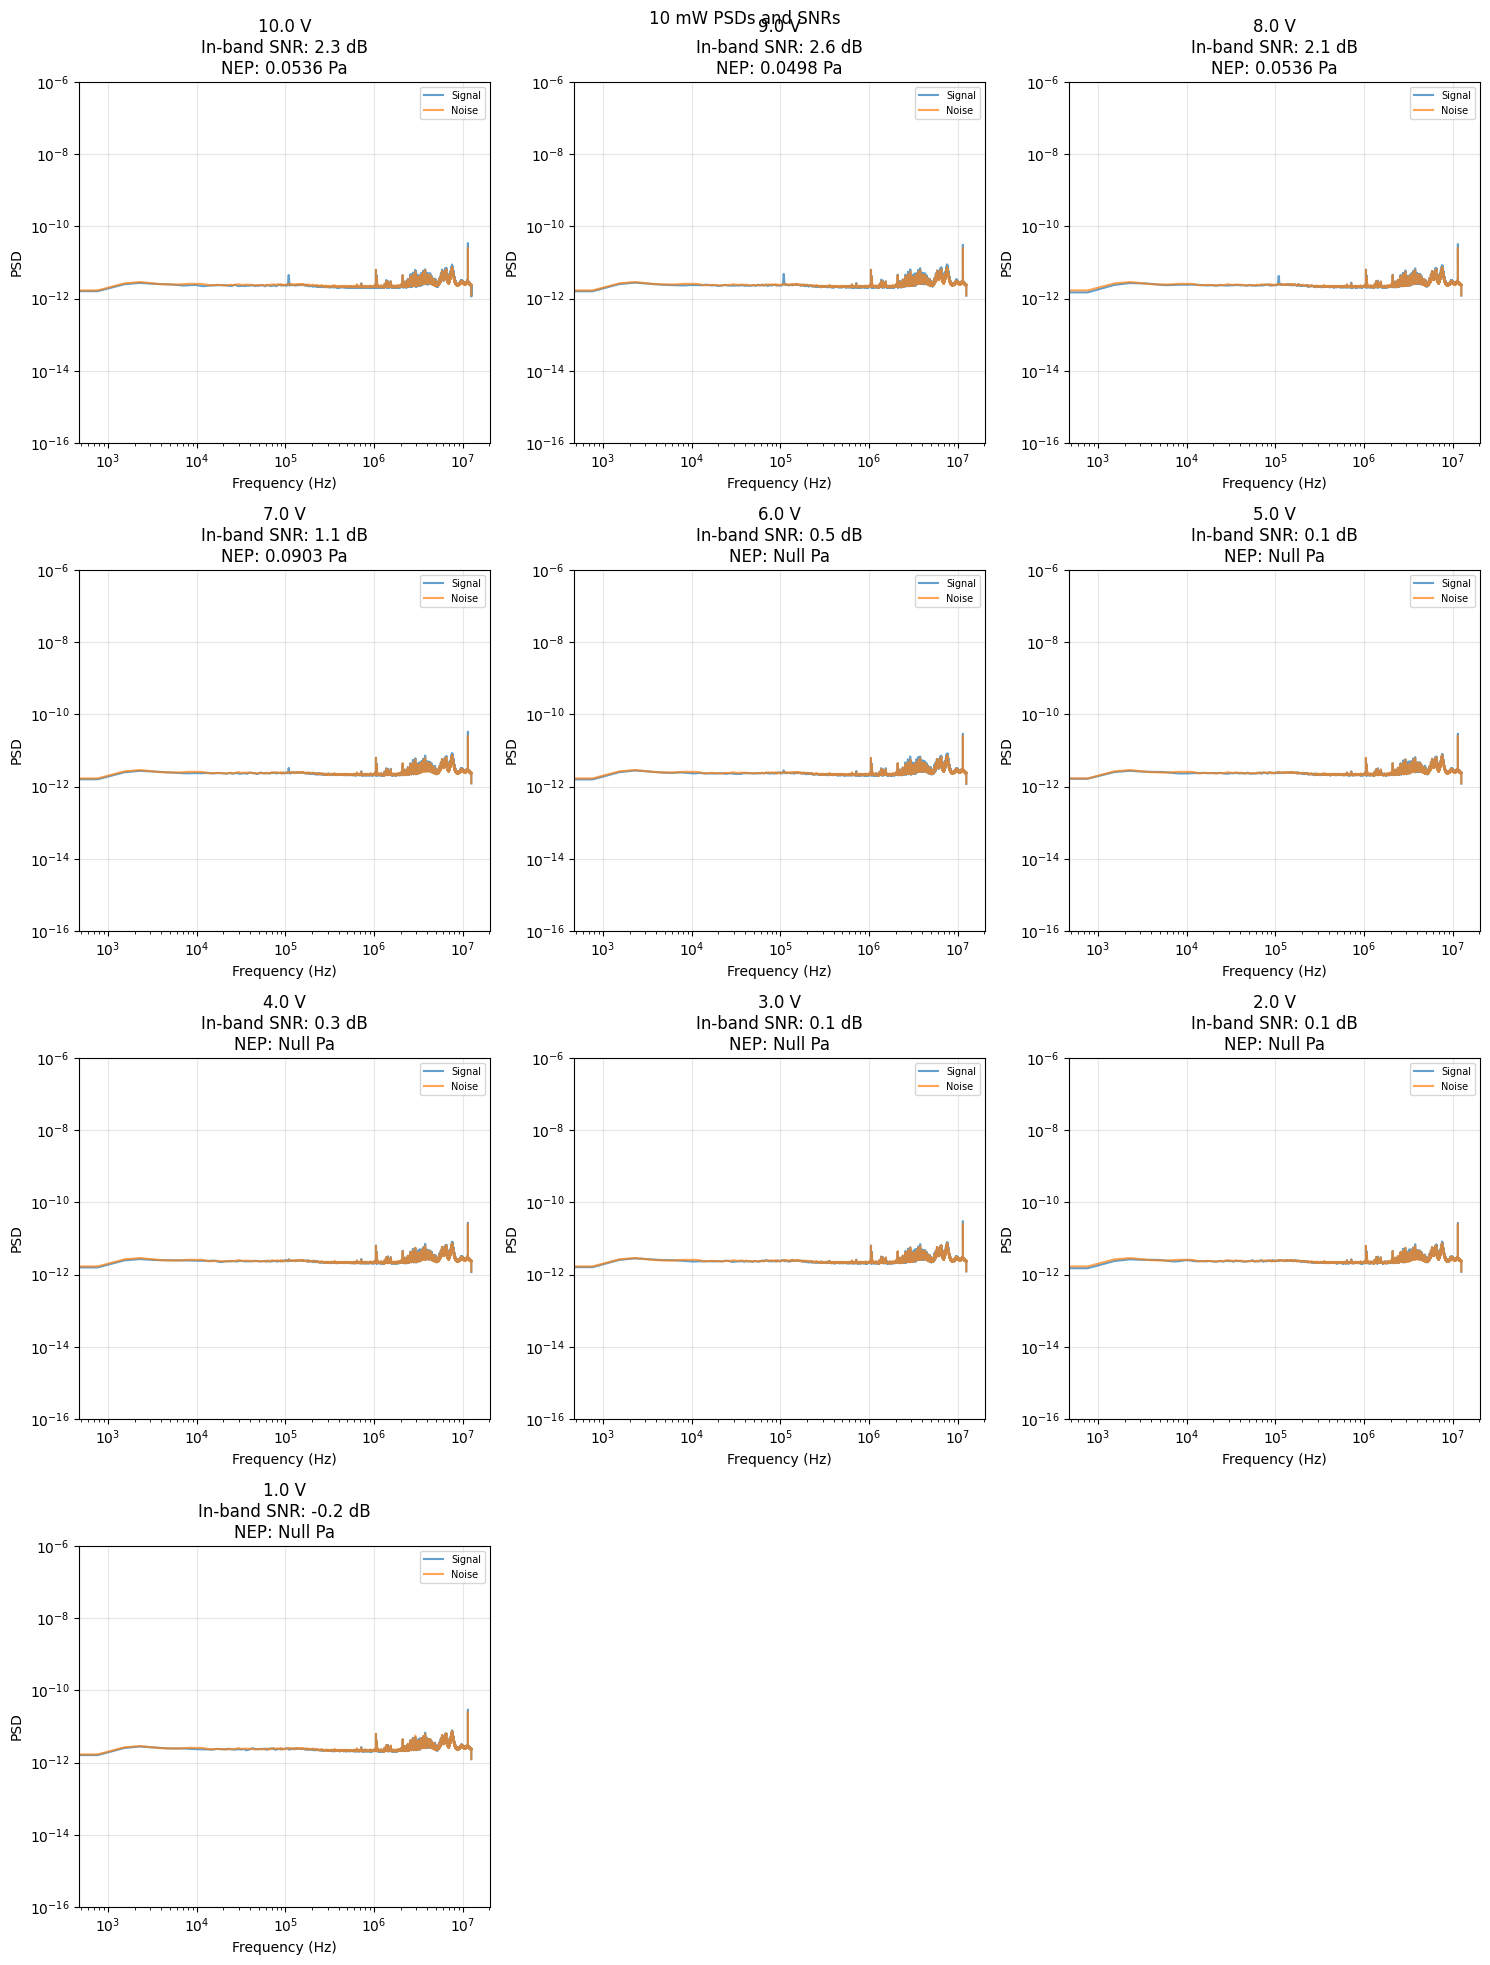

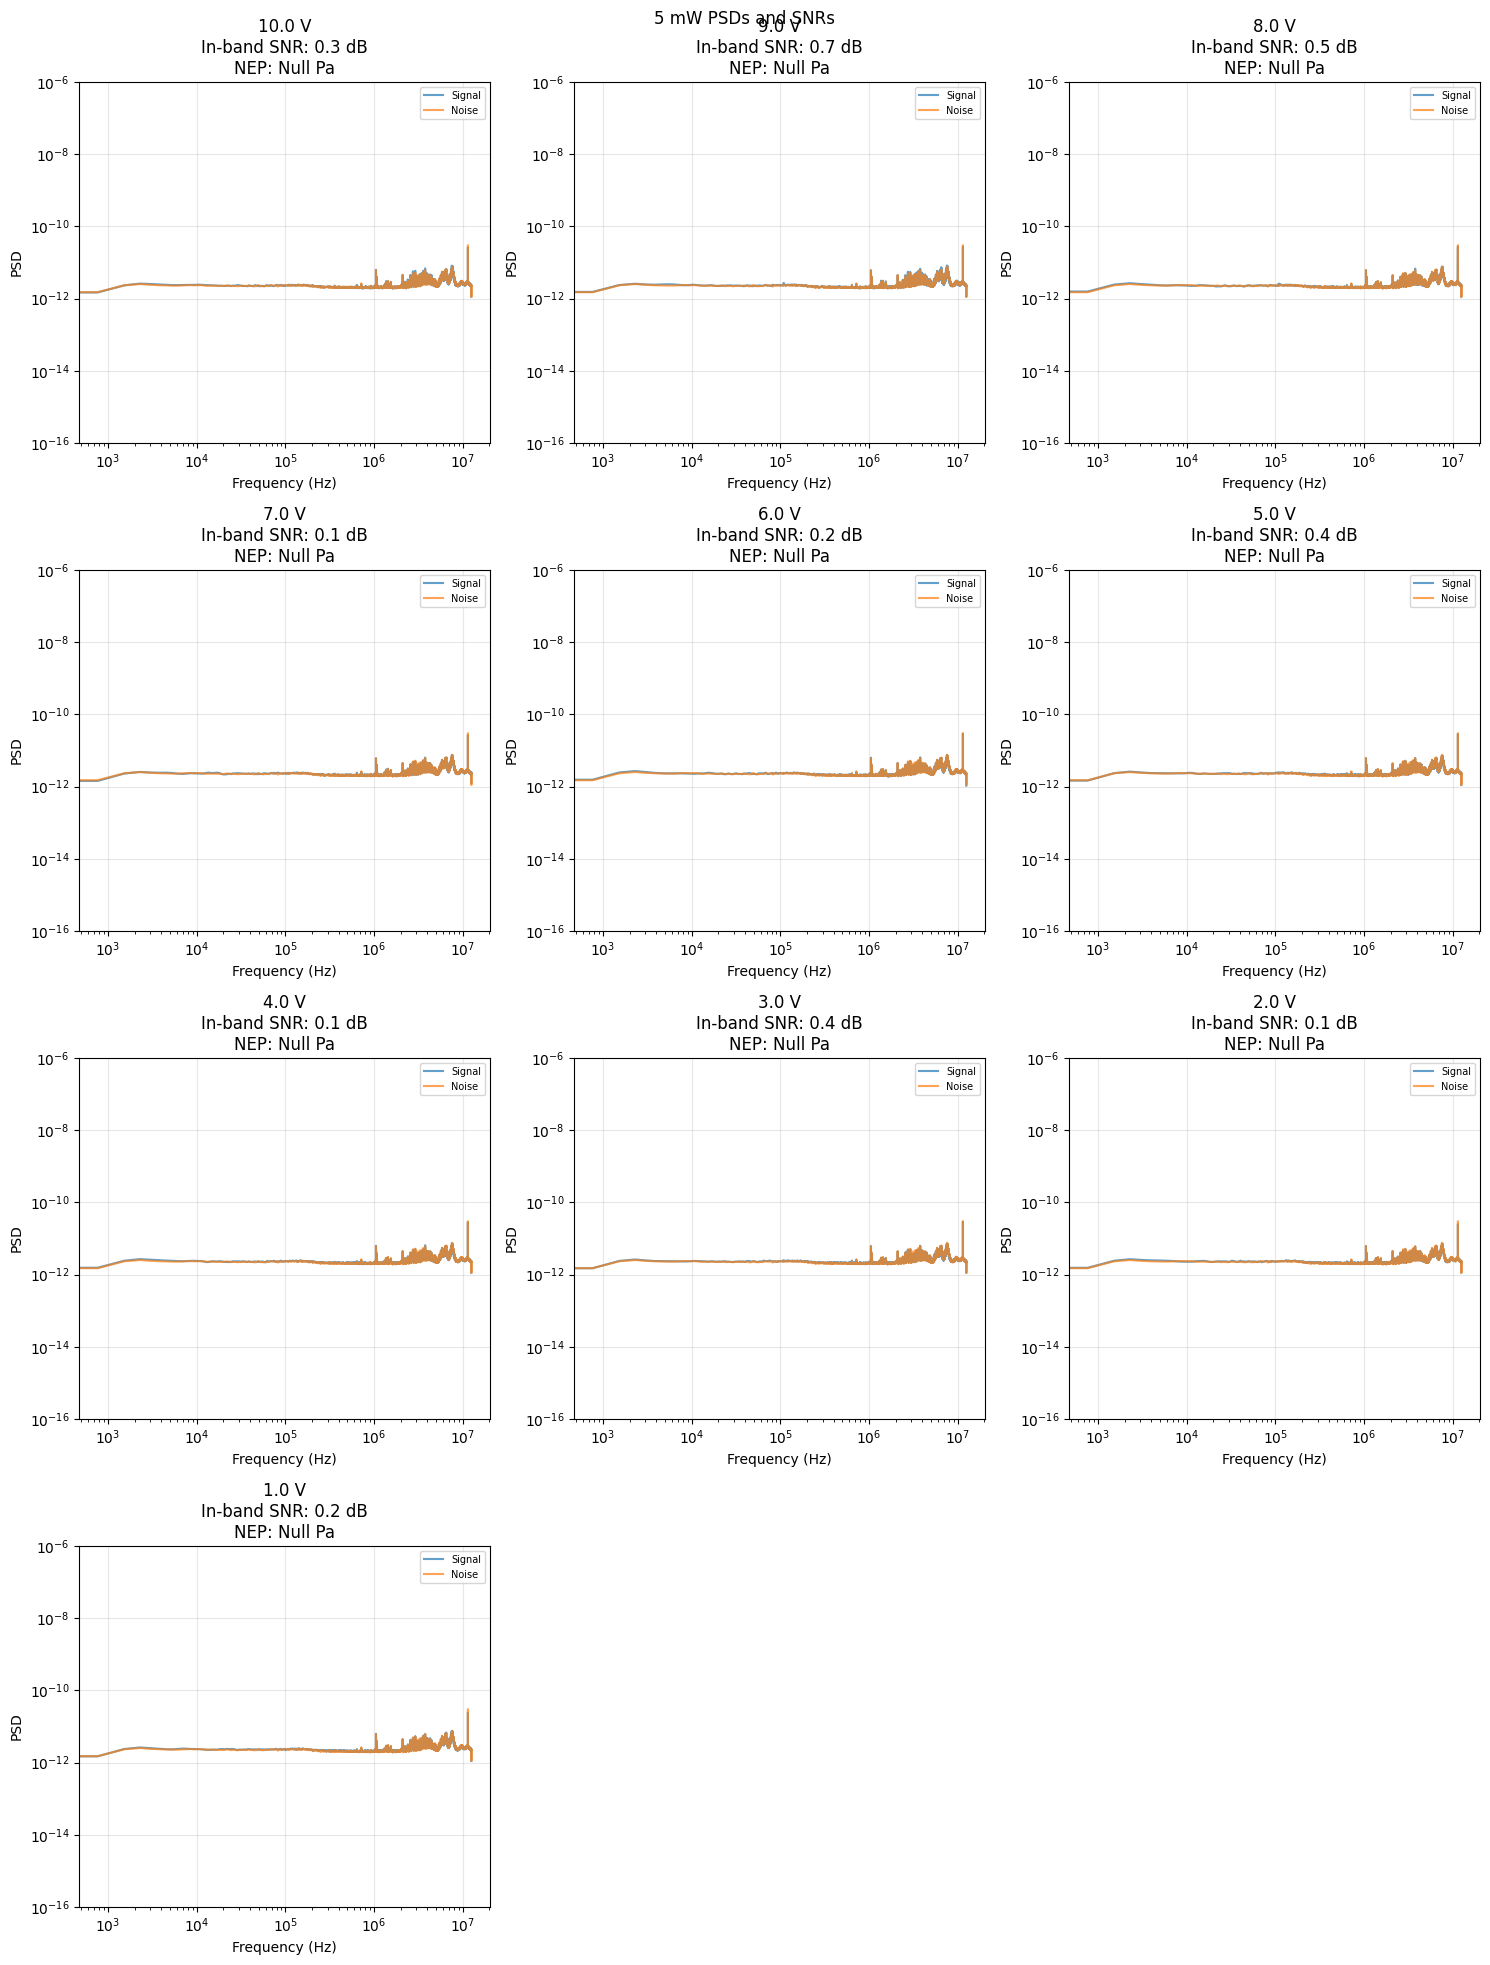

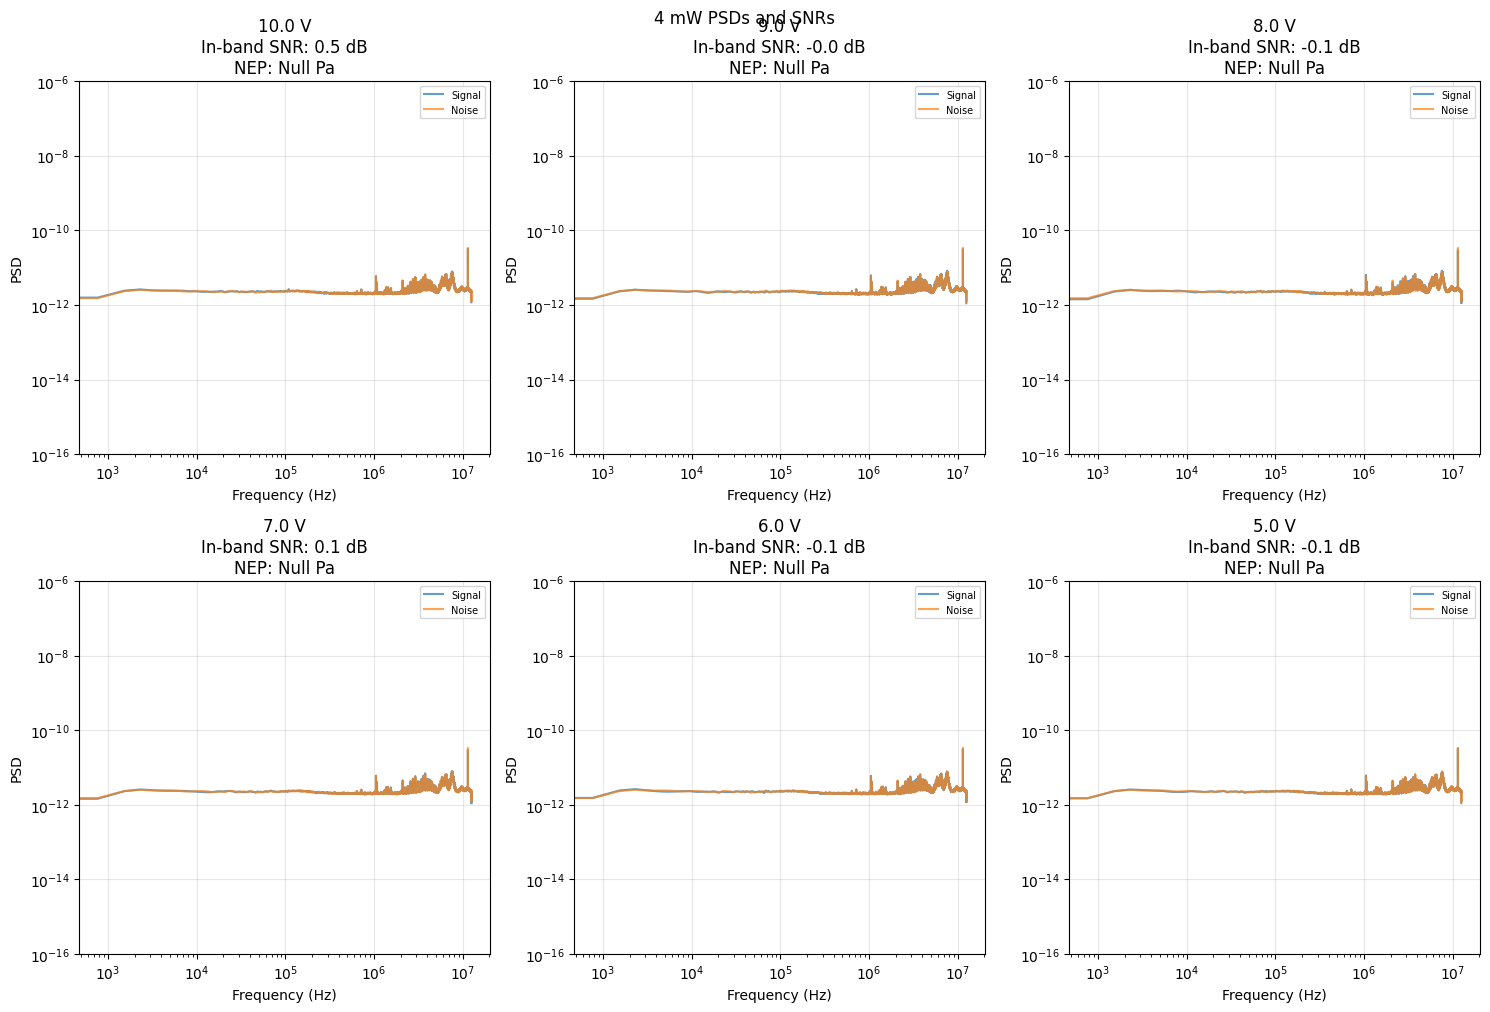

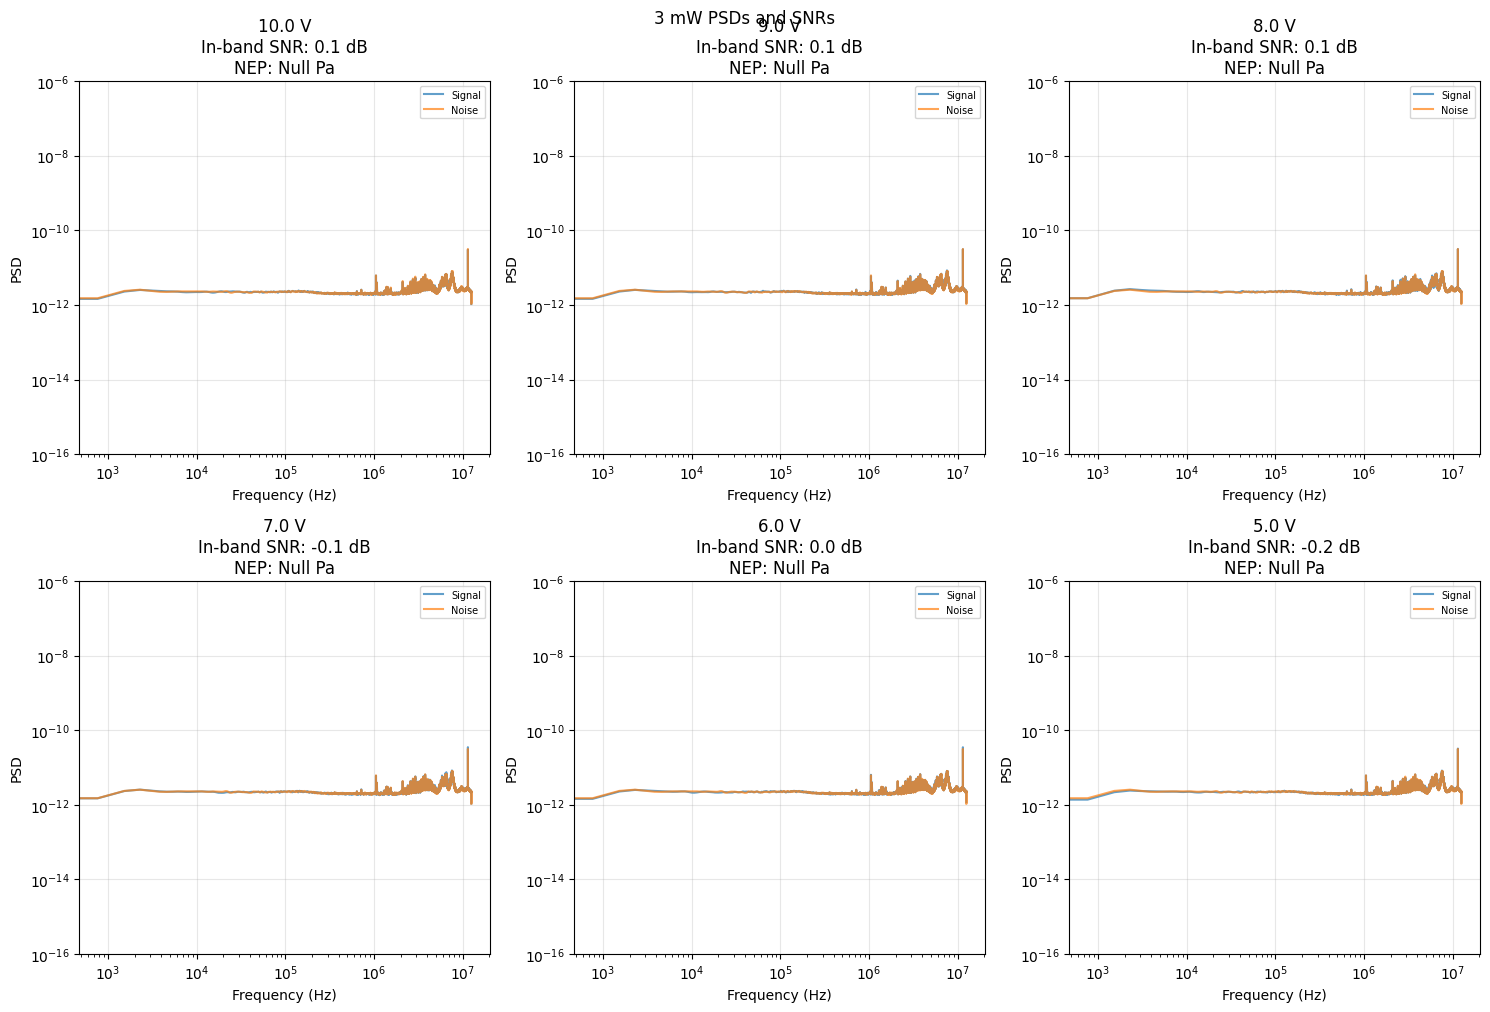

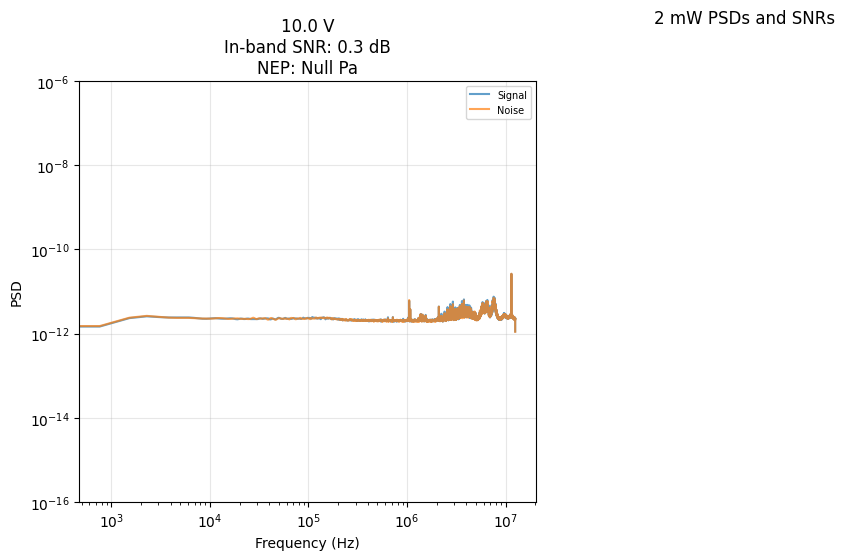

In [105]:
#the big kahoona

power_levels = [21, 15, 10, 5, 4, 3, 2]
fig3, ax3 = plt.subplots(figsize=(6, 4))

for power in power_levels:
    results = analysis_welches(power, base_path)
    voltage_values = sorted(results.keys())
    snr_values = [results[voltage]["snr_inband"] for voltage in voltage_values]

    ax3.plot(voltage_values, snr_values, "o-", label=f"{power} mW")

ax3.set_xlabel("Voltage (V)")
ax3.set_ylabel("In-band SNR (dB)")
ax3.set_title("SNR vs voltage")
ax3.grid(True, alpha=0.3)
ax3.legend()
fig3.tight_layout()
plt.show()

##PSD generated via periodogram. More jagged, herder to read PSD, but higher SNR values.

Analyzing pof_21mW: found 10 voltage scans
  Processing pof_21mW_109kHz_10V with 5 signal files and 5 noise files
    In-band SNR: 7.04 dB | Wideband SNR: 0.06 dB
    NEP: 0.0177 Pa
  Processing pof_21mW_109kHz_9V with 5 signal files and 5 noise files
    In-band SNR: 9.37 dB | Wideband SNR: 0.09 dB
    NEP: 0.0139 Pa
  Processing pof_21mW_109kHz_8V with 5 signal files and 5 noise files
    In-band SNR: 8.51 dB | Wideband SNR: 0.06 dB
    NEP: 0.0133 Pa
  Processing pof_21mW_109kHz_7V with 5 signal files and 5 noise files
    In-band SNR: 6.62 dB | Wideband SNR: 0.10 dB
    NEP: 0.015 Pa
  Processing pof_21mW_109kHz_6V with 5 signal files and 5 noise files
    In-band SNR: 4.70 dB | Wideband SNR: 0.12 dB
    NEP: 0.0181 Pa
  Processing pof_21mW_109kHz_5V with 5 signal files and 5 noise files
    In-band SNR: 4.65 dB | Wideband SNR: 0.12 dB
    NEP: 0.0146 Pa
  Processing pof_21mW_109kHz_4V with 5 signal files and 5 noise files
    In-band SNR: 2.83 dB | Wideband SNR: 0.12 dB
    NEP: 0

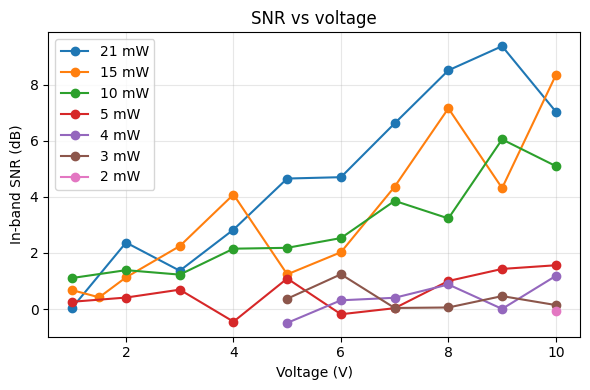

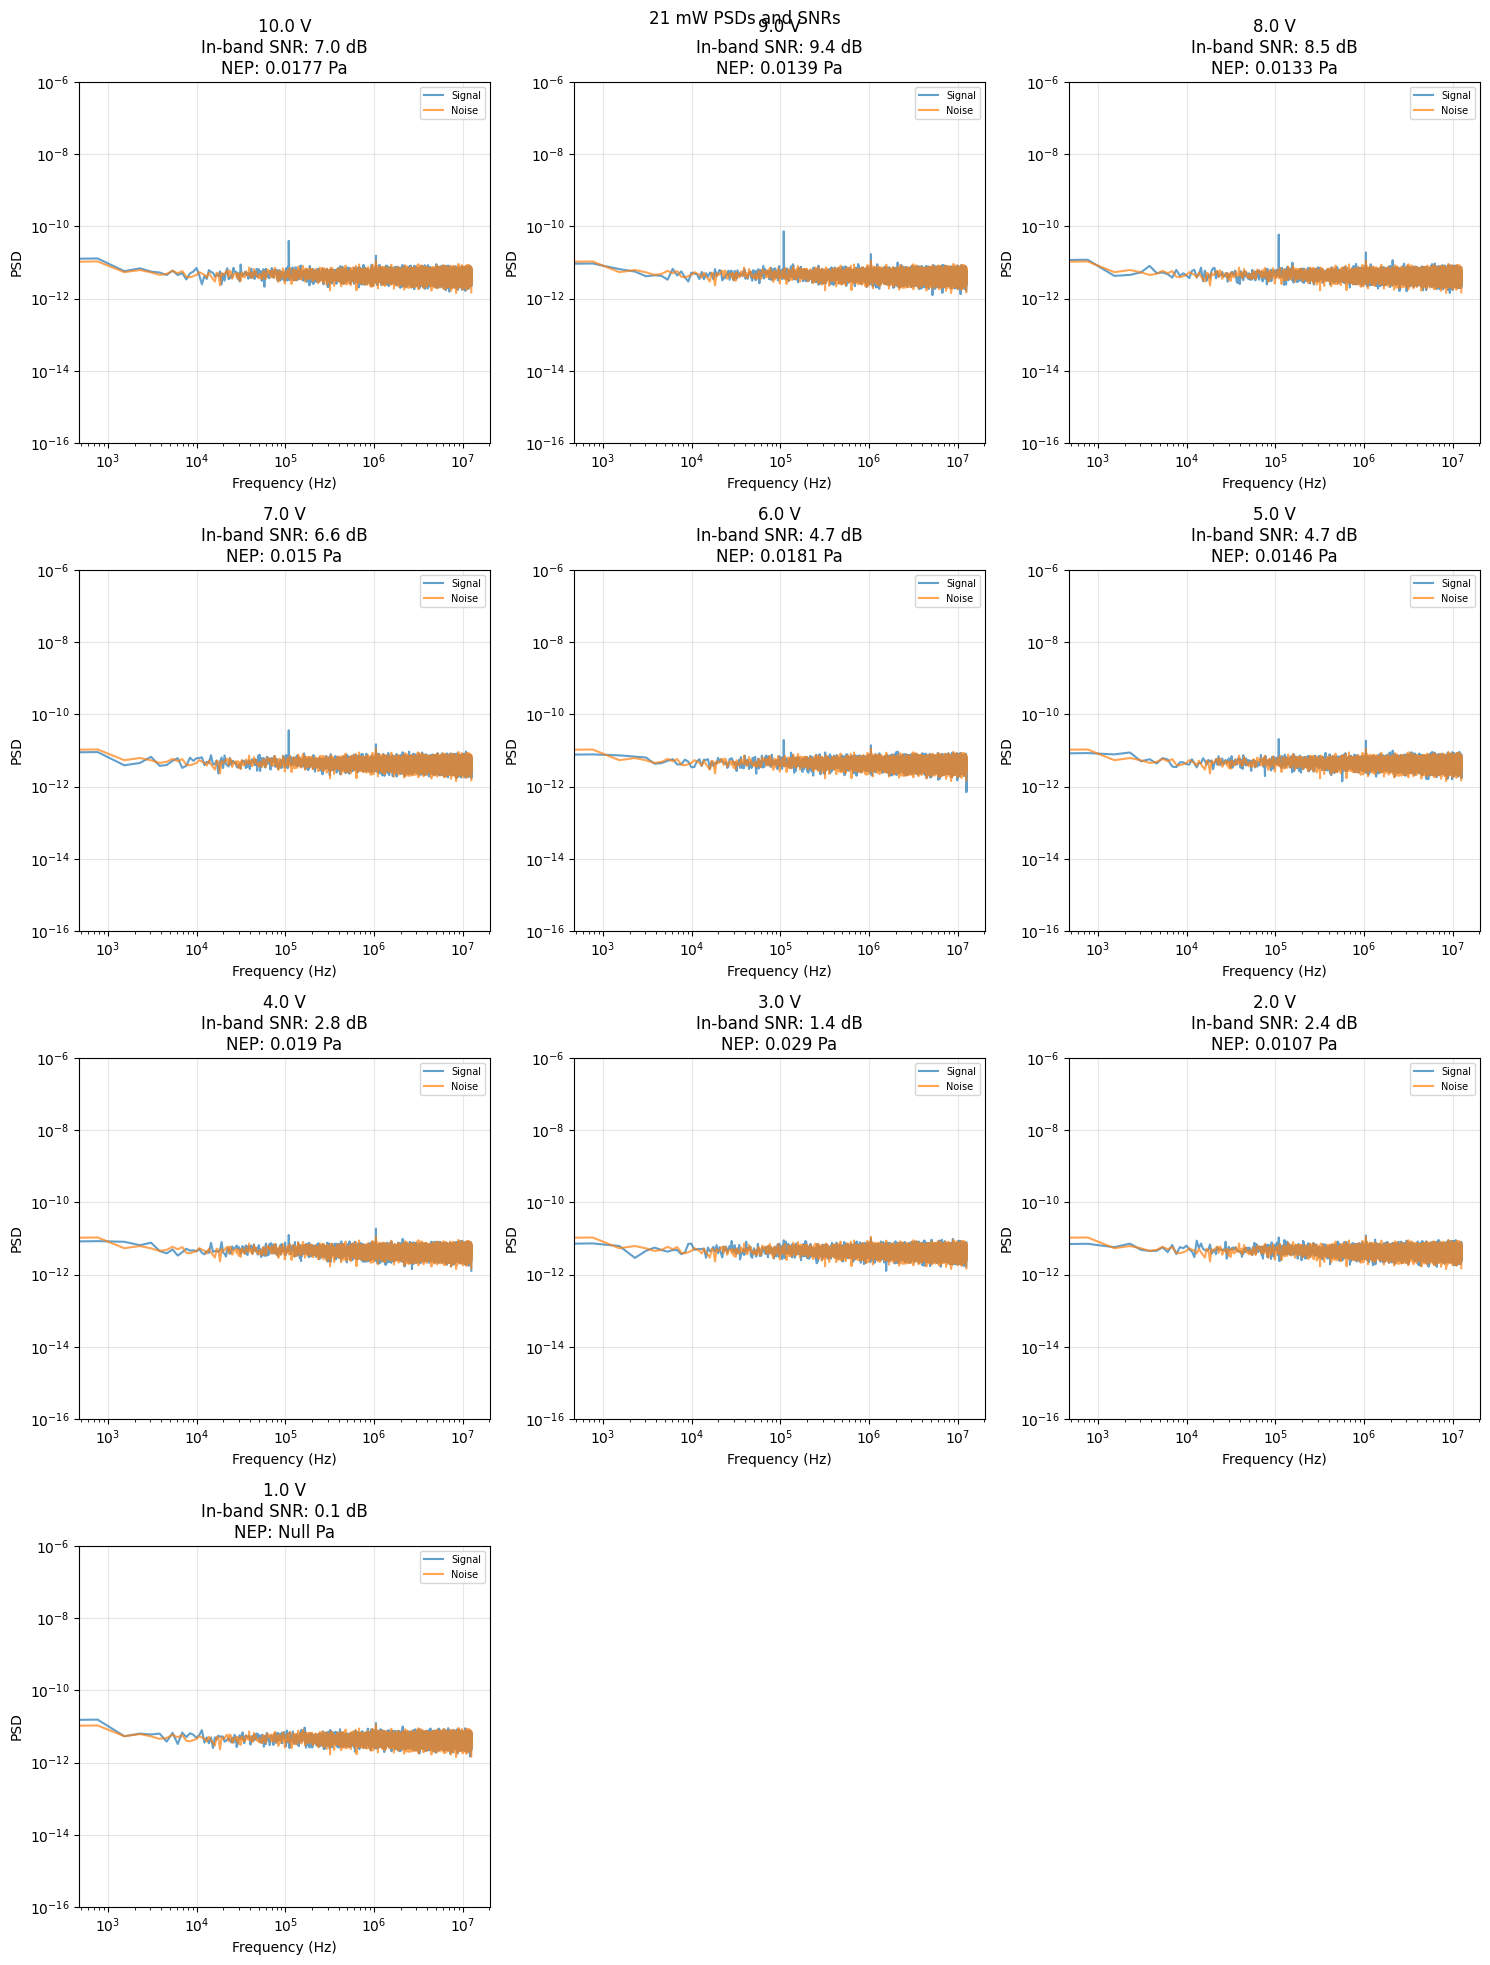

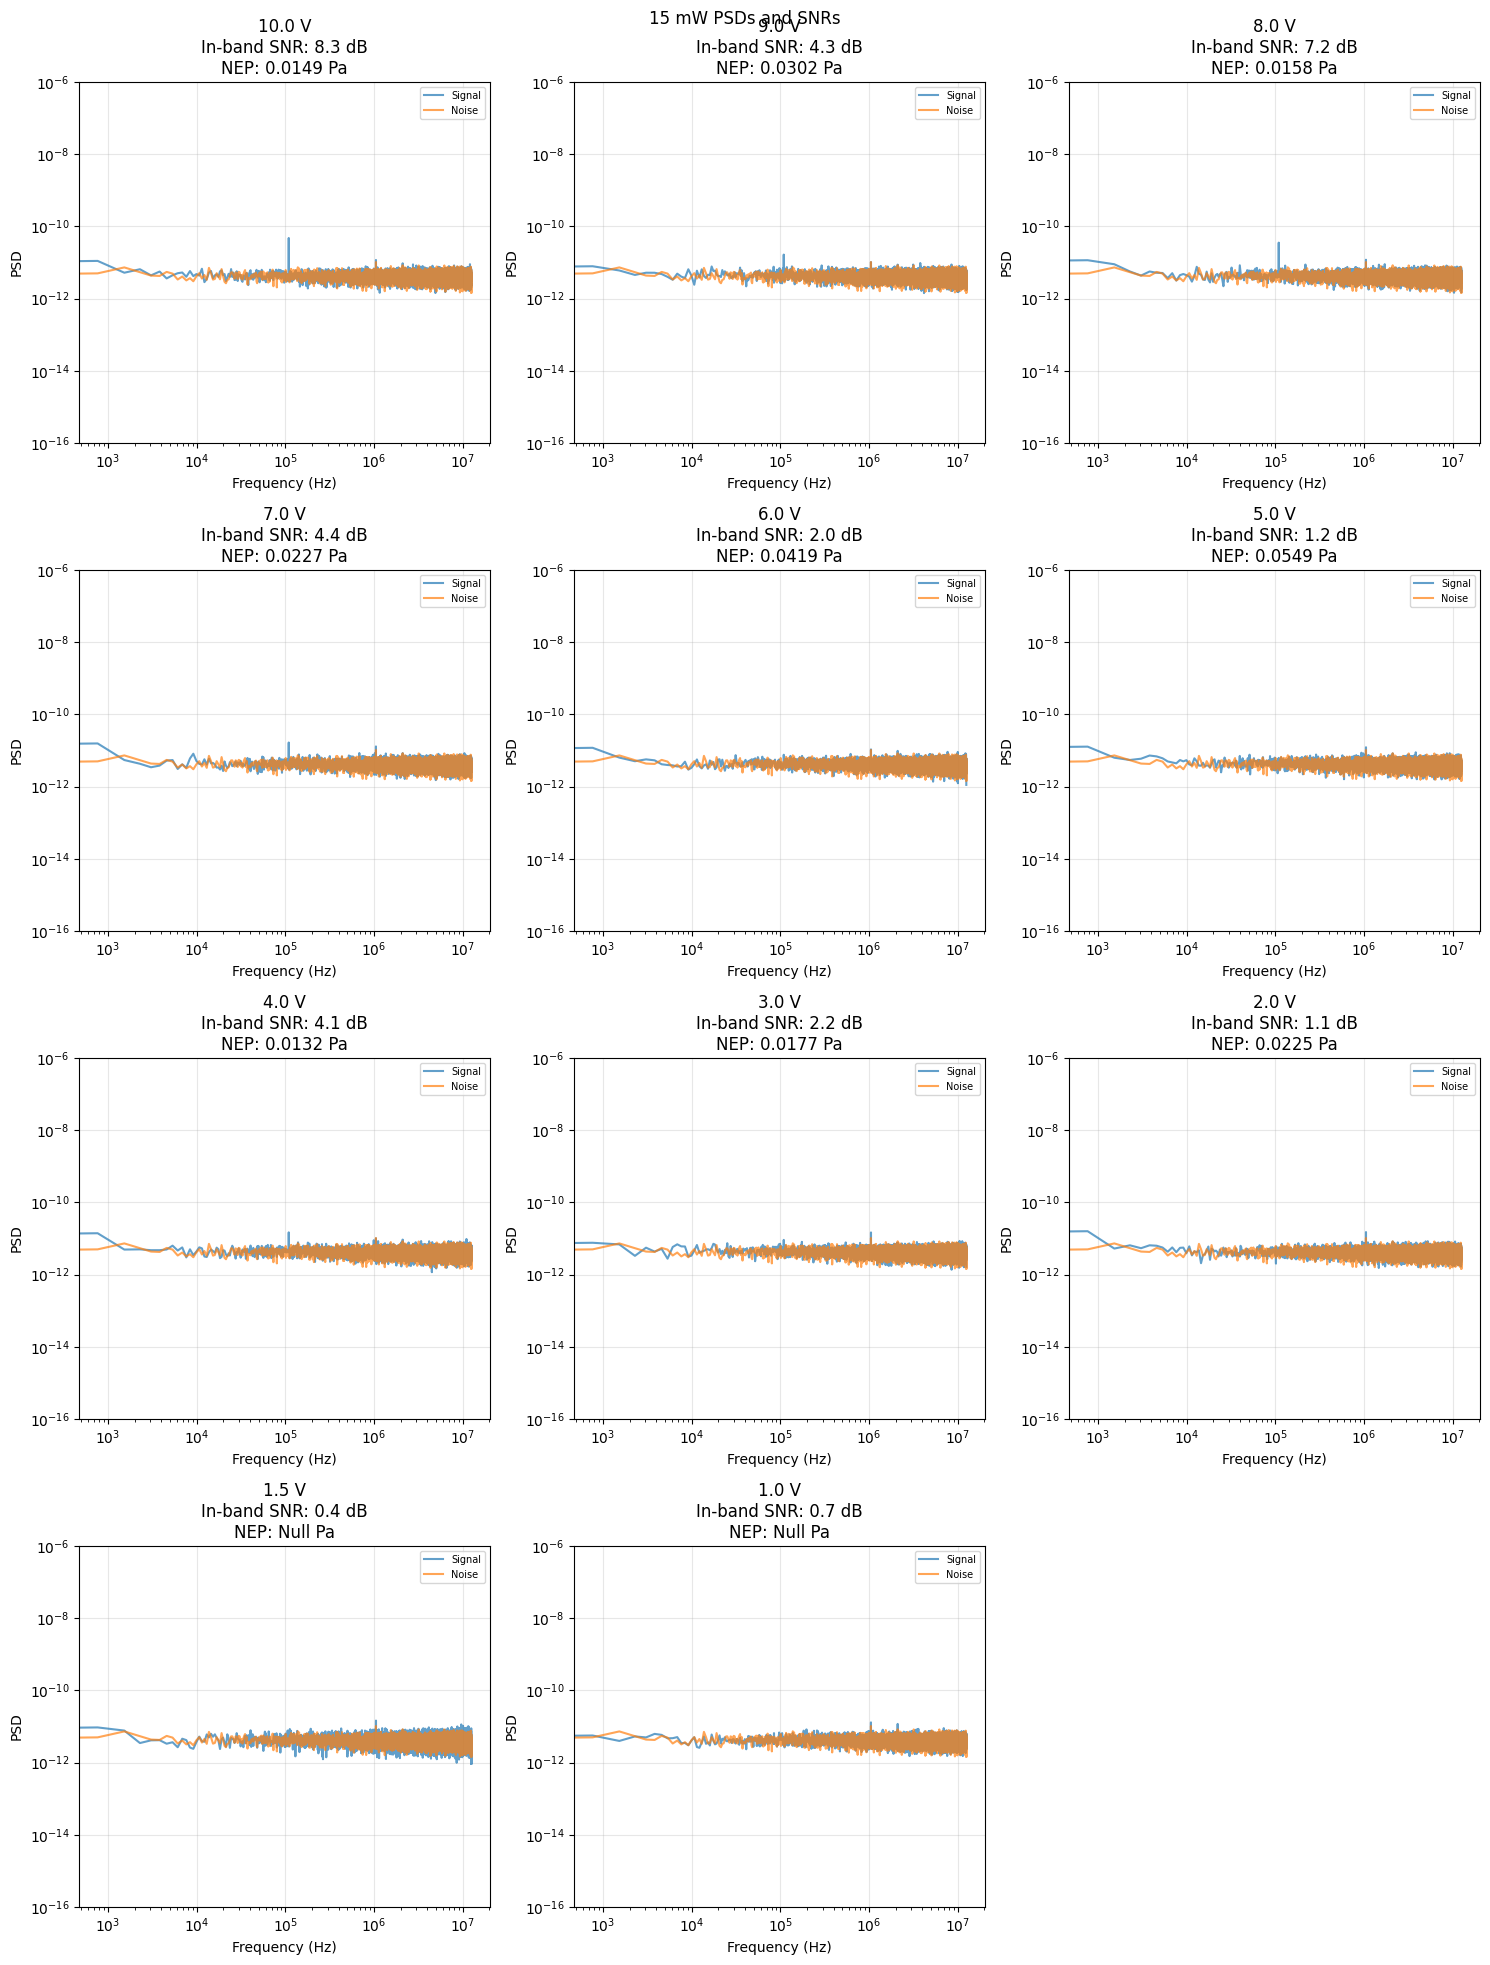

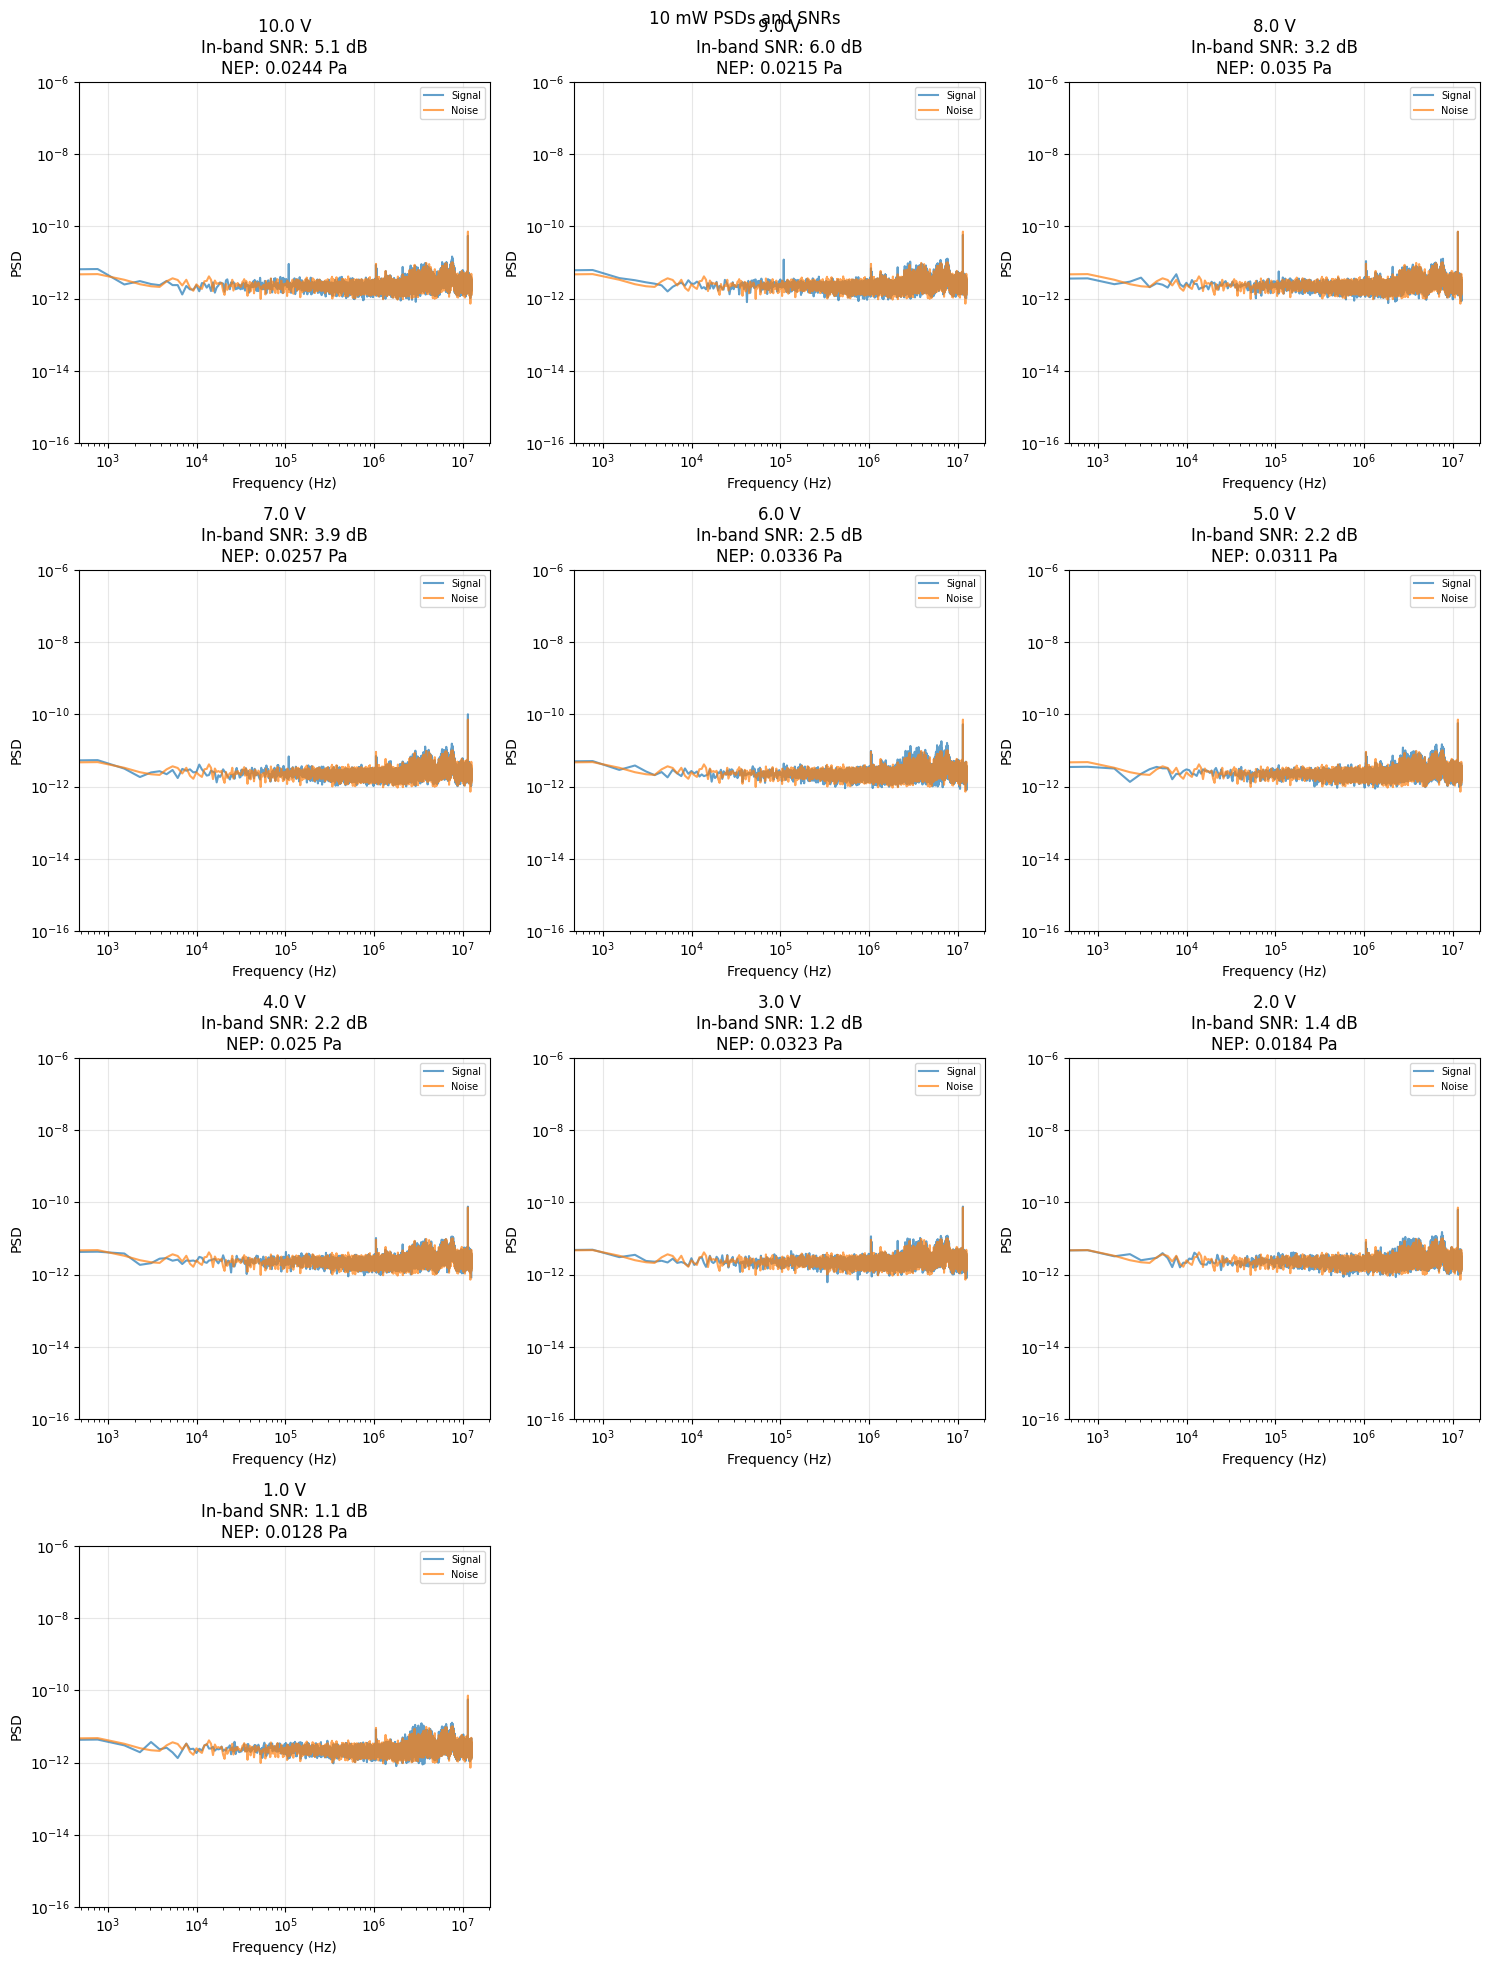

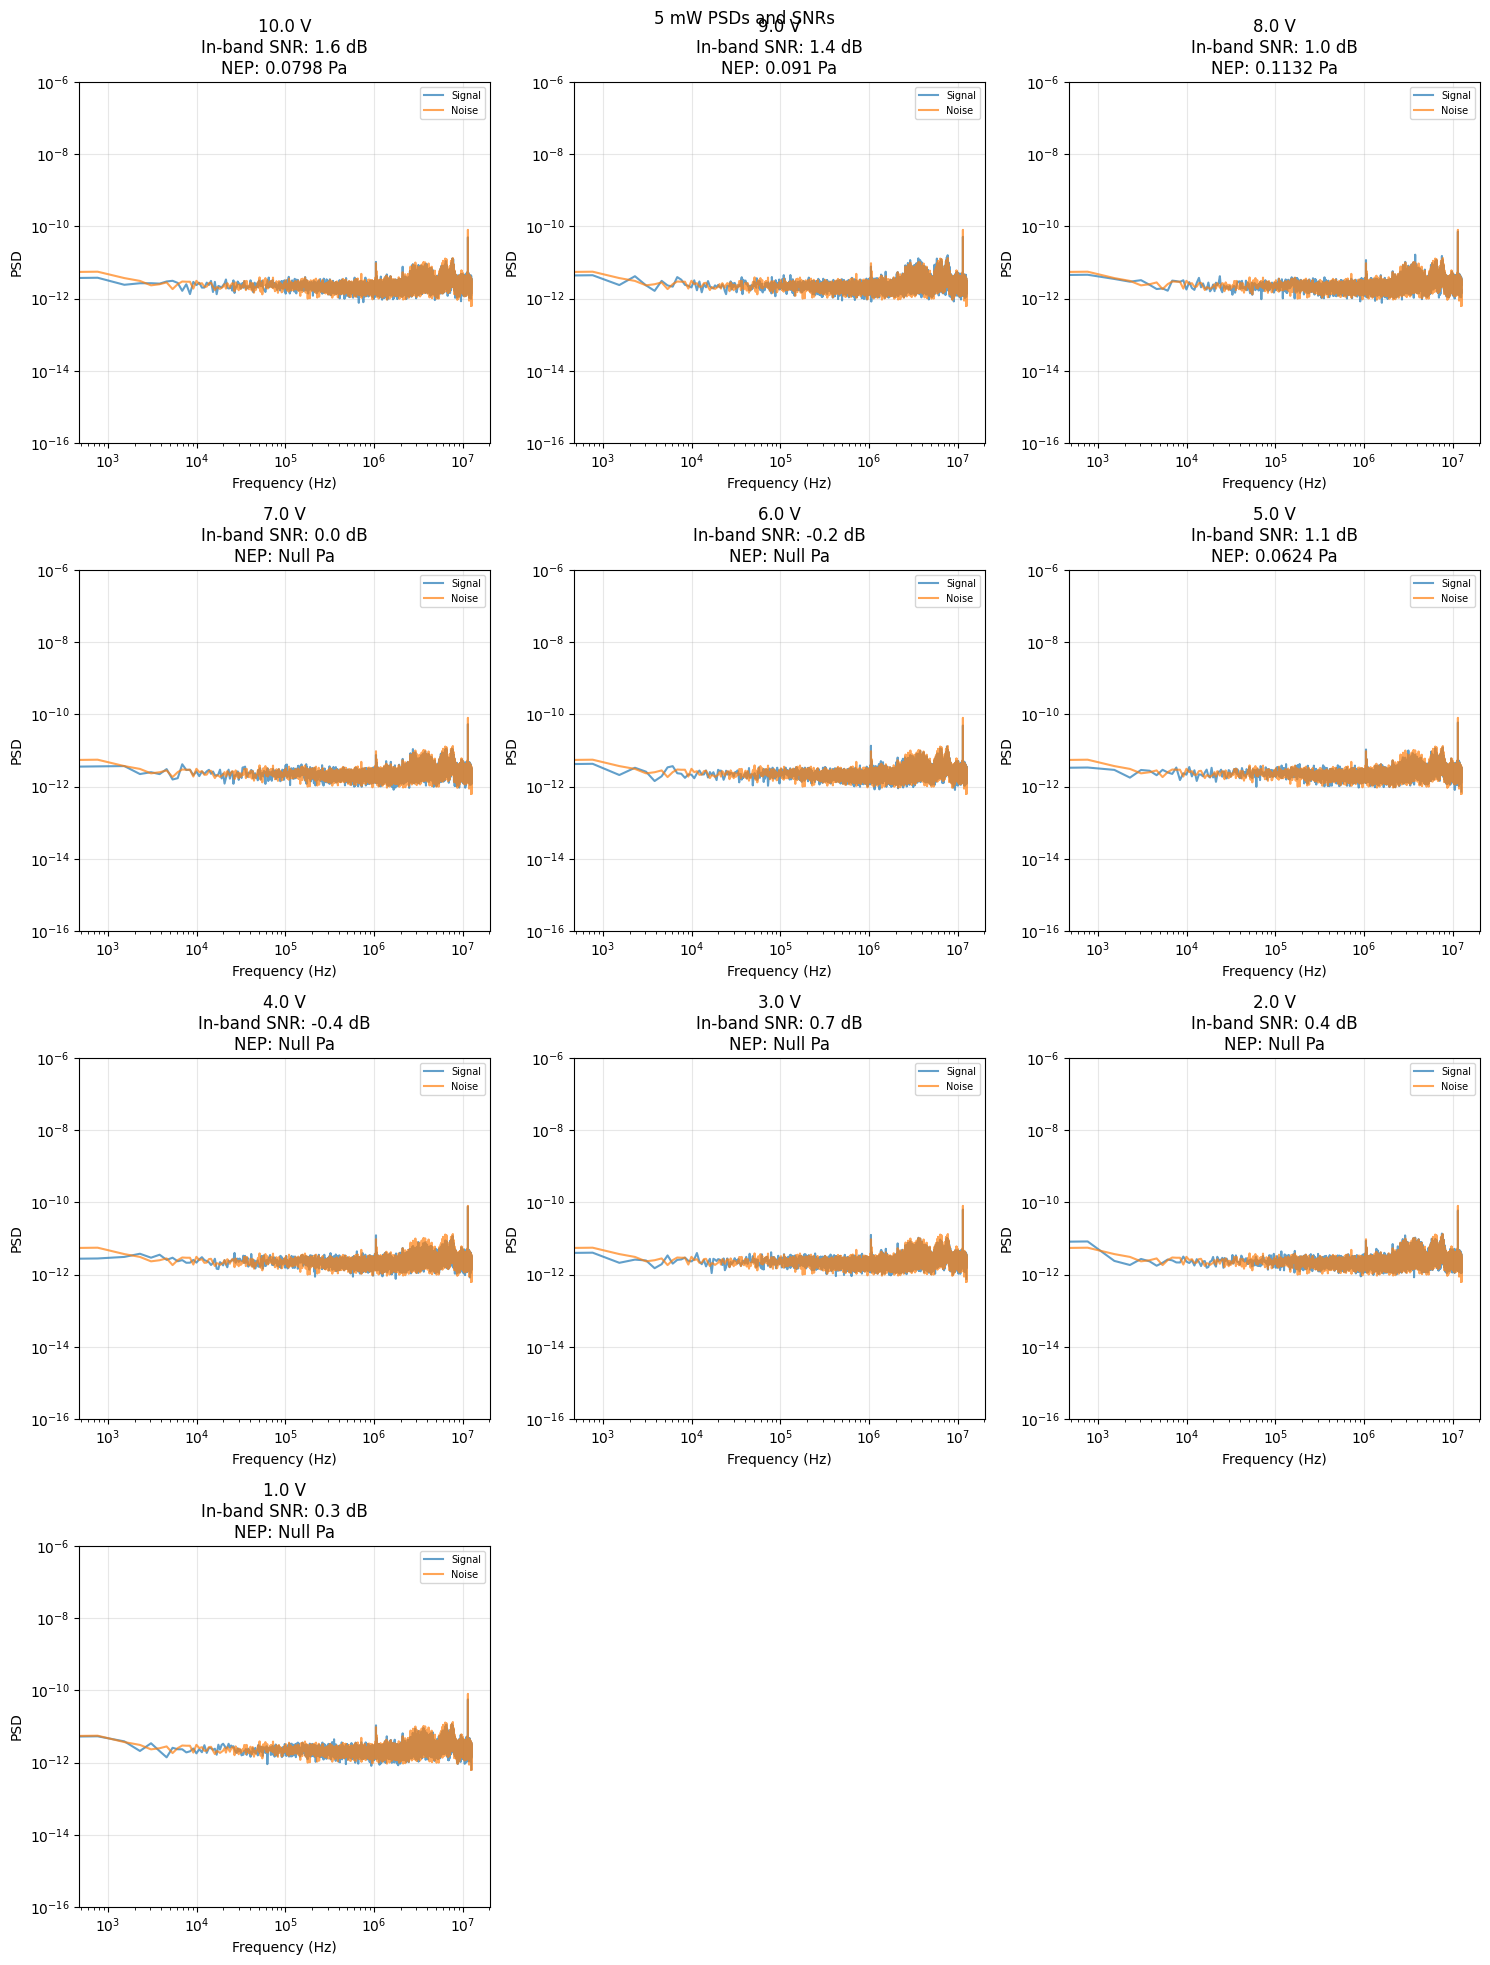

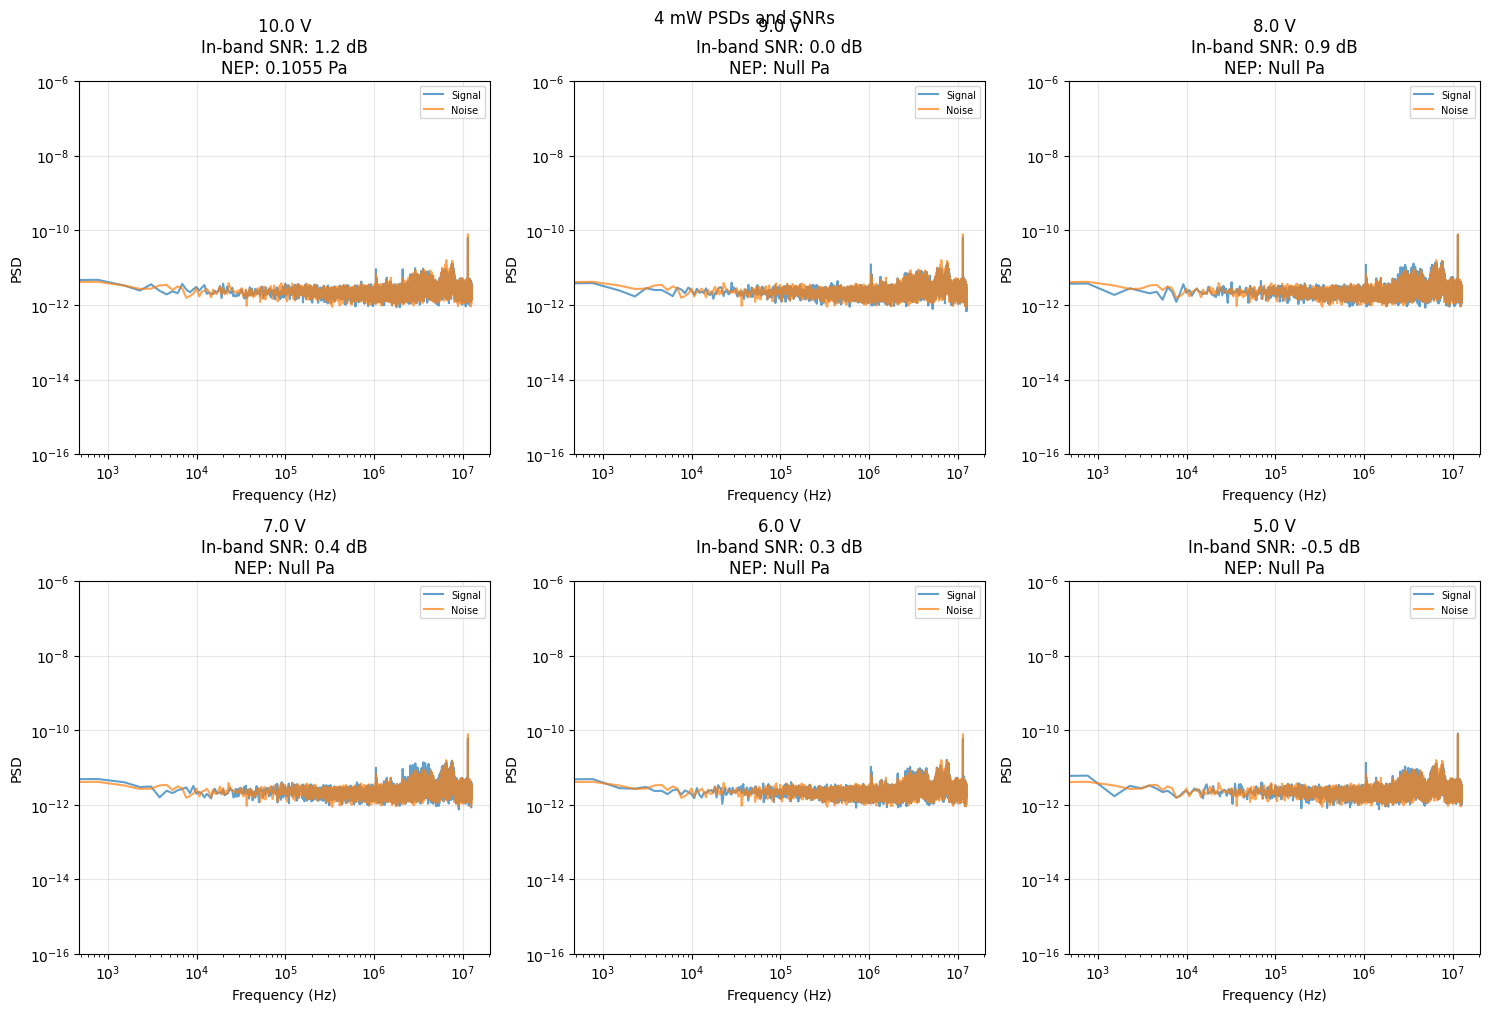

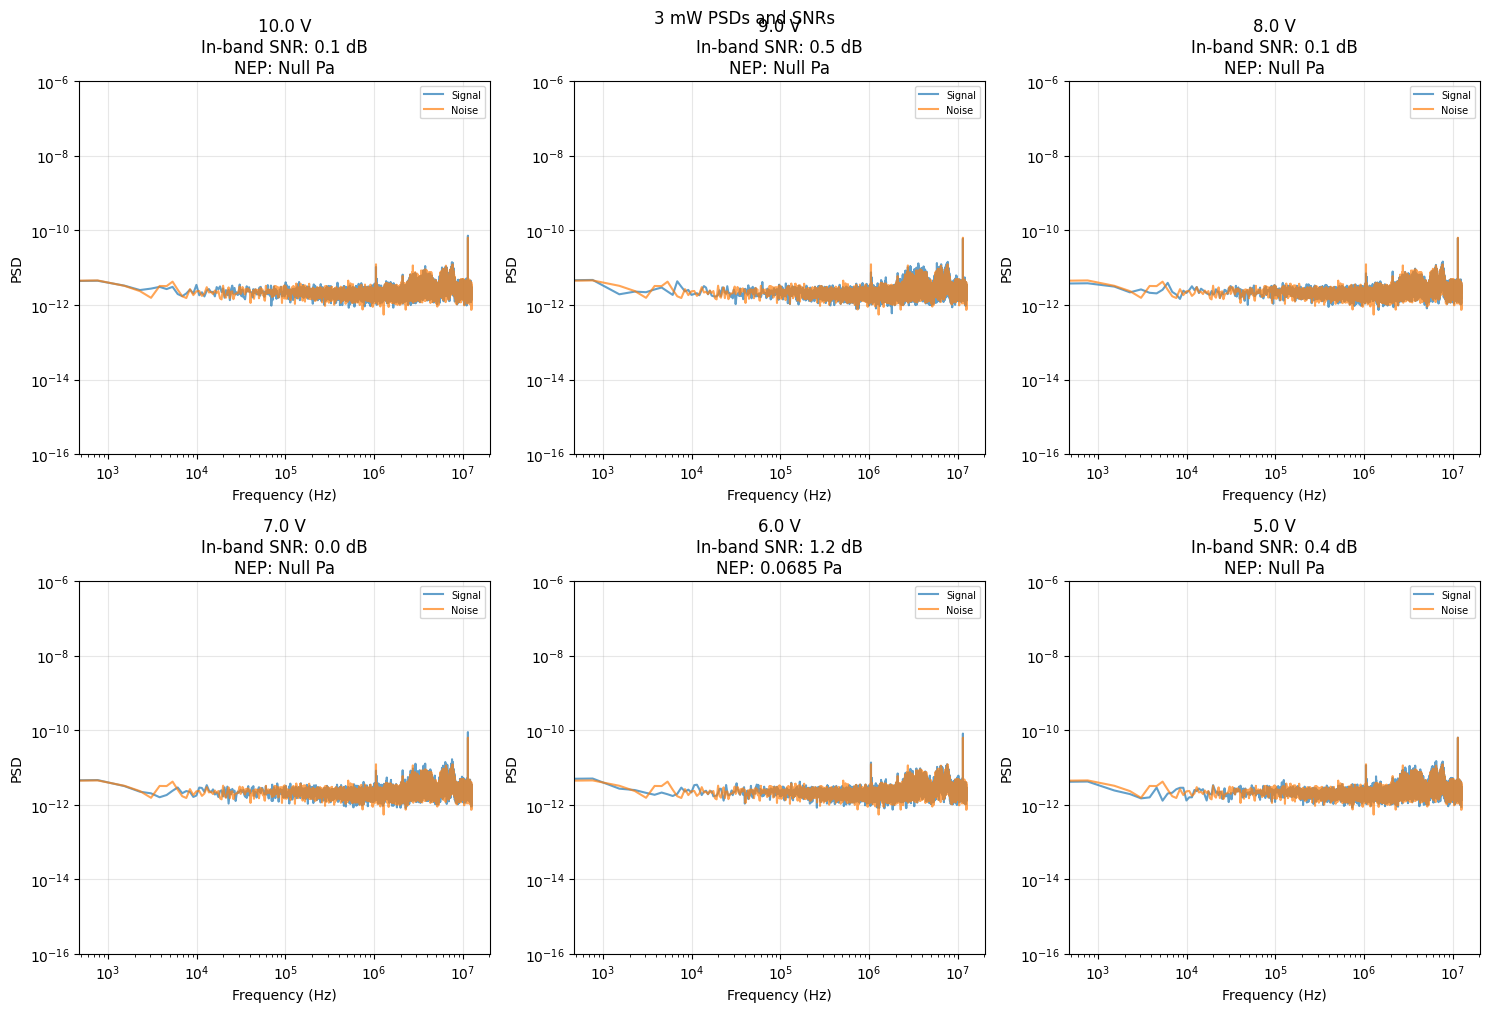

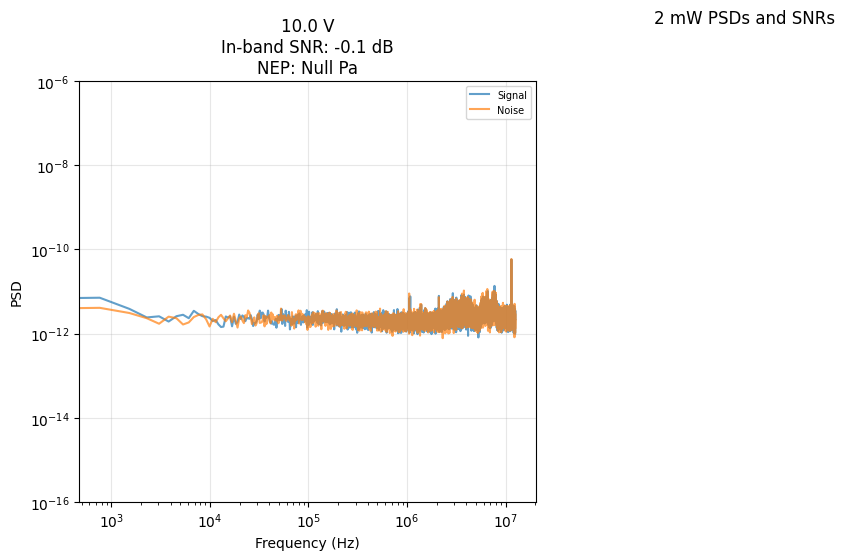

In [112]:
#the big kahoona 2

power_levels = [21, 15, 10, 5, 4, 3, 2]
fig3, ax3 = plt.subplots(figsize=(6, 4))

for power in power_levels:
    results = analysis_periodogram(power, base_path)
    voltage_values = sorted(results.keys())
    snr_values = [results[voltage]["snr_inband"] for voltage in voltage_values]

    ax3.plot(voltage_values, snr_values, "o-", label=f"{power} mW")

ax3.set_xlabel("Voltage (V)")
ax3.set_ylabel("In-band SNR (dB)")
ax3.set_title("SNR vs voltage")
ax3.grid(True, alpha=0.3)
ax3.legend()
fig3.tight_layout()
plt.show()